# Participatory Budgeting Analysis: Comparing Proportional Voting Methods

## Term Project - Analysis of Wieliczka Green Budget 2023

In this notebook, we analyze a real-world participatory budgeting election from Wieliczka, Poland, and compare multiple **proportional voting methods** to understand their trade-offs in fairness, efficiency, and representation.

### What is Participatory Budgeting?

Participatory budgeting (PB) is a democratic process where citizens directly decide how to spend part of a public budget. Voters approve projects they support, and an algorithm selects which projects to fund.

### Voting Methods Compared

We implement and compare **5 different voting methods**:

| Method | Description |
|--------|-------------|
| **MES (Method of Equal Shares)** | Each voter gets an equal budget share; projects funded when supporters can collectively afford them |
| **MES + Add1** | MES with greedy completion to maximize budget utilization |
| **Phragmén's Sequential Method** | Minimizes maximum "load" on any voter - balances representation |
| **SPAV (Sequential Proportional Approval)** | Reweights votes after each selection using d'Hondt divisors |
| **Greedy Approval** | Simply picks most popular projects (baseline, non-proportional) |

### Dataset

- **Location**: Wieliczka, Poland (Green Budget / Zielony Milion)
- **Year**: 2023
- **Budget**: 1,000,000 PLN
- **Projects**: 64
- **Voters**: 6,586
- **Voting type**: Approval voting (no maximum)

Let's explore how these methods compare in terms of fairness, voter satisfaction, and budget efficiency!


## 1. Setup and Data Loading

First, let's import the libraries we need and load the data.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# For interactive maps
try:
    import folium
    from folium.plugins import HeatMap, MarkerCluster
    FOLIUM_AVAILABLE = True
except ImportError:
    print("Installing folium for interactive maps...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'folium', '-q'])
    import folium
    from folium.plugins import HeatMap, MarkerCluster
    FOLIUM_AVAILABLE = True

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [ ]:
def parse_pabulib_file(filepath):
    """
    Parse a .pb file in pabulib format.
    This format has three sections: META, PROJECTS, and VOTES
    """
    metadata = {}
    projects = []
    votes = []

    current_section = None
    project_headers = None
    vote_headers = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Check for section headers
            if line == 'META':
                current_section = 'META'
                continue
            elif line == 'PROJECTS':
                current_section = 'PROJECTS'
                continue
            elif line == 'VOTES':
                current_section = 'VOTES'
                continue

            # Parse based on current section
            if current_section == 'META':
                if ';' in line and line != 'key;value':
                    key, value = line.split(';', 1)
                    metadata[key] = value

            elif current_section == 'PROJECTS':
                parts = line.split(';')
                if project_headers is None:
                    project_headers = parts
                else:
                    project = dict(zip(project_headers, parts))
                    projects.append(project)

            elif current_section == 'VOTES':
                parts = line.split(';')
                if vote_headers is None:
                    vote_headers = parts
                else:
                    vote_dict = dict(zip(vote_headers, parts))
                    votes.append(vote_dict)

    return metadata, projects, votes

# Load the data
filepath = 'poland_wieliczka_2023_green-budget.pb'
metadata, projects_raw, votes_raw = parse_pabulib_file(filepath)

print("Data loaded successfully!")
print(f"Number of projects: {len(projects_raw)}")
print(f"Number of votes: {len(votes_raw)}")

Data loaded successfully!
Number of projects: 64
Number of votes: 6586


In [ ]:
# Let's look at the metadata
print("=" * 50)
print("ELECTION METADATA")
print("=" * 50)

for key, value in metadata.items():
    print(f"{key}: {value}")

ELECTION METADATA
description: Municipal PB in Wieliczka, Green Budget (Zielony Milion)
country: Poland
unit: Wieliczka
subunit: Green Budget
instance: 2023
num_projects: 64
num_votes: 6586
budget: 1000000
vote_type: approval
rule: equalshares/add1
date_begin: 03.04.2023
date_end: 21.04.2023
min_length: 1
edition: 1
language: pl
currency: PLN


## 2. Data Exploration

Now let's convert the data into pandas DataFrames and explore it a bit. This will help us understand what we're working with.

In [ ]:
# Create projects DataFrame
projects_df = pd.DataFrame(projects_raw)

# Convert numeric columns
projects_df['cost'] = pd.to_numeric(projects_df['cost'])
projects_df['votes'] = pd.to_numeric(projects_df['votes'])
projects_df['selected'] = pd.to_numeric(projects_df['selected']).astype(bool)
projects_df['latitude'] = pd.to_numeric(projects_df['latitude'], errors='coerce')
projects_df['longitude'] = pd.to_numeric(projects_df['longitude'], errors='coerce')

# Show basic info
print(f"Projects DataFrame shape: {projects_df.shape}")
print(f"\nColumn types:")
print(projects_df.dtypes)

projects_df.head(10)

Projects DataFrame shape: (64, 7)

Column types:
project_id     object
cost            int64
votes           int64
name           object
selected         bool
latitude      float64
longitude     float64
dtype: object


,project_id,cost,votes,name,selected,latitude,longitude
0,24,5000,720,Zakup 10 fotopułapek przeciwko śmieciarzom i d...,True,49.987392,20.083598
1,41,85000,658,Stworzenie warunków rekreacyjnych dla mieszkań...,True,50.017056,20.114811
2,40,100000,583,Projekt zapobiegania bezdomności psów i kotów ...,True,49.984696,20.059132
3,74,70800,552,Rewitalizacja zieleni parku przy kościele św. ...,True,49.978246,20.066024
4,19,99800,538,Odbudowa populacji zagrożonych gatunków ichtio...,True,50.032776,20.083137
5,6,100000,500,Zielona Chorągwica - rewitalizacja terenów zie...,True,49.957871,20.089838
6,21,100000,496,Budowa ścieżki edukacyjno-ekologicznej w Lasko...,False,49.956080,20.068717
7,32,34999,428,Nasadzenie drzew krzewów i traw przy nowo budo...,True,50.009518,20.101901
8,39,600,418,Budki lęgowe dla jerzyków,True,50.013634,20.093511
9,58,32716,400,Zielony skwerek przy Szkole Podstawowej im. Kr...,True,49.971577,20.040496


In [ ]:
# Process voting data
# Each voter can vote for multiple projects (approval voting)

votes_data = []
for vote in votes_raw:
    voter_id = vote['voter_id']
    # The vote field contains comma-separated project IDs
    project_ids = vote['vote'].split(',') if vote['vote'] else []
    votes_data.append({
        'voter_id': voter_id,
        'projects_voted': project_ids,
        'num_projects': len(project_ids)
    })

votes_df = pd.DataFrame(votes_data)

print(f"Total voters: {len(votes_df)}")
print(f"\nVoting statistics:")
print(votes_df['num_projects'].describe())

Total voters: 6586

Voting statistics:
count    6586.000000
mean        2.543274
std         3.727347
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        64.000000
Name: num_projects, dtype: float64


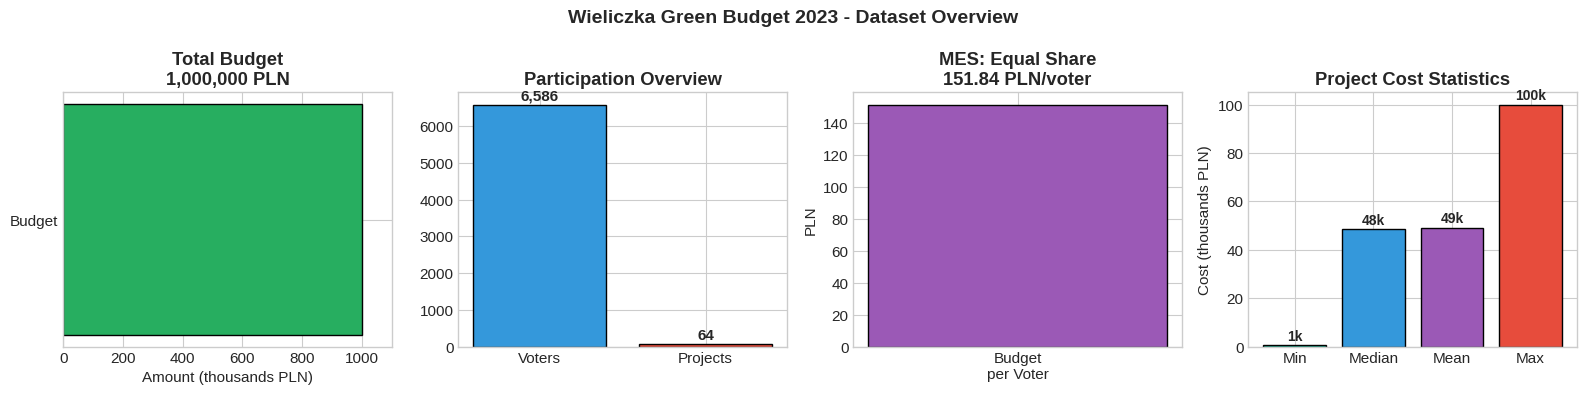

In [ ]:
# Visualize key statistics
budget = int(metadata['budget'])
num_voters = int(metadata['num_votes'])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. Budget overview
axes[0].barh(['Budget'], [budget/1000], color='#27ae60', edgecolor='black', height=0.5)
axes[0].set_xlabel('Amount (thousands PLN)')
axes[0].set_title(f'Total Budget\n{budget:,} PLN', fontweight='bold')
axes[0].set_xlim(0, budget/1000 * 1.1)

# 2. Voters and Projects
categories = ['Voters', 'Projects']
values = [num_voters, len(projects_df)]
colors = ['#3498db', '#e74c3c']
bars = axes[1].bar(categories, values, color=colors, edgecolor='black')
axes[1].set_title('Participation Overview', fontweight='bold')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# 3. Budget per voter (for MES)
budget_per_voter = budget / num_voters
axes[2].bar(['Budget\nper Voter'], [budget_per_voter], color='#9b59b6', edgecolor='black', width=0.4)
axes[2].set_ylabel('PLN')
axes[2].set_title(f'MES: Equal Share\n{budget_per_voter:.2f} PLN/voter', fontweight='bold')

# 4. Project cost stats
cost_stats = {
    'Min': projects_df['cost'].min(),
    'Median': projects_df['cost'].median(),
    'Mean': projects_df['cost'].mean(),
    'Max': projects_df['cost'].max()
}
bars = axes[3].bar(cost_stats.keys(), [v/1000 for v in cost_stats.values()],
                   color=['#1abc9c', '#3498db', '#9b59b6', '#e74c3c'], edgecolor='black')
axes[3].set_ylabel('Cost (thousands PLN)')
axes[3].set_title('Project Cost Statistics', fontweight='bold')
for bar, val in zip(bars, cost_stats.values()):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val/1000:.0f}k', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Wieliczka Green Budget 2023 - Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Visualizing the Data

Let's create some visualizations to better understand the projects and voting patterns.

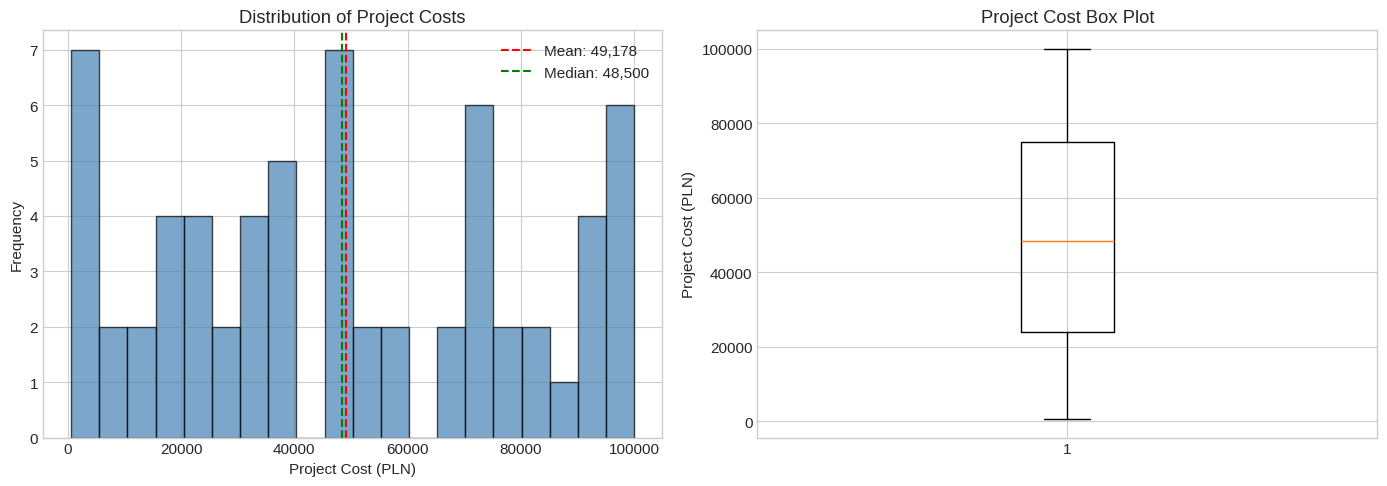

In [ ]:
# Distribution of project costs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of costs
axes[0].hist(projects_df['cost'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(projects_df['cost'].mean(), color='red', linestyle='--', label=f'Mean: {projects_df["cost"].mean():,.0f}')
axes[0].axvline(projects_df['cost'].median(), color='green', linestyle='--', label=f'Median: {projects_df["cost"].median():,.0f}')
axes[0].set_xlabel('Project Cost (PLN)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Project Costs')
axes[0].legend()

# Box plot
axes[1].boxplot(projects_df['cost'], vert=True)
axes[1].set_ylabel('Project Cost (PLN)')
axes[1].set_title('Project Cost Box Plot')

plt.tight_layout()
plt.show()

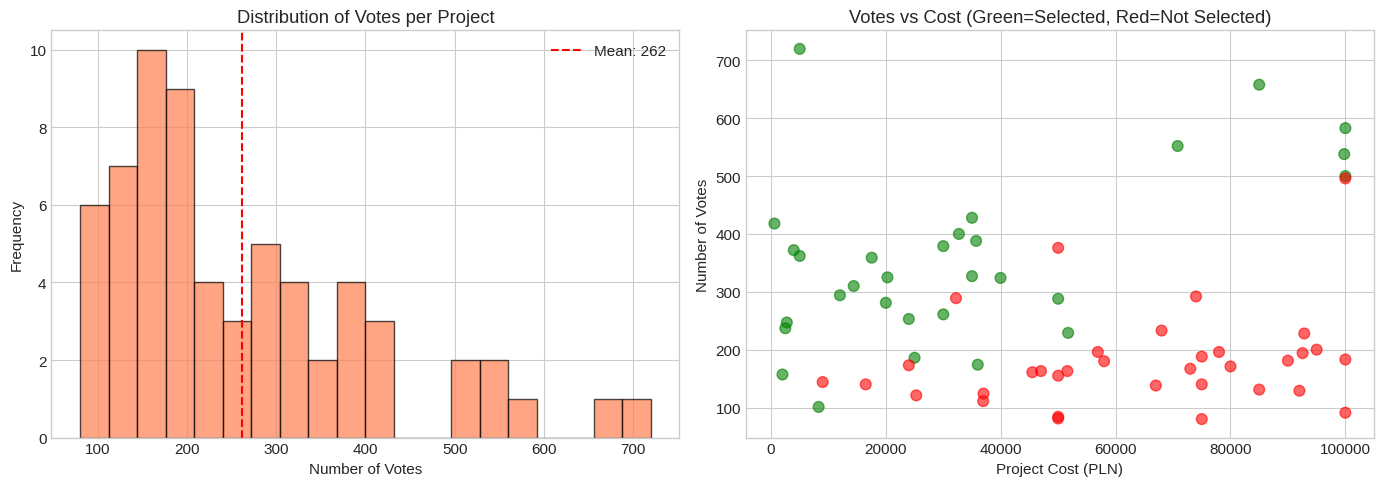

In [ ]:
# Distribution of votes per project
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of votes
axes[0].hist(projects_df['votes'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(projects_df['votes'].mean(), color='red', linestyle='--', label=f'Mean: {projects_df["votes"].mean():,.0f}')
axes[0].set_xlabel('Number of Votes')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Votes per Project')
axes[0].legend()

# Votes vs Cost scatter
colors = ['green' if s else 'red' for s in projects_df['selected']]
axes[1].scatter(projects_df['cost'], projects_df['votes'], c=colors, alpha=0.6, s=60)
axes[1].set_xlabel('Project Cost (PLN)')
axes[1].set_ylabel('Number of Votes')
axes[1].set_title('Votes vs Cost (Green=Selected, Red=Not Selected)')

plt.tight_layout()
plt.show()

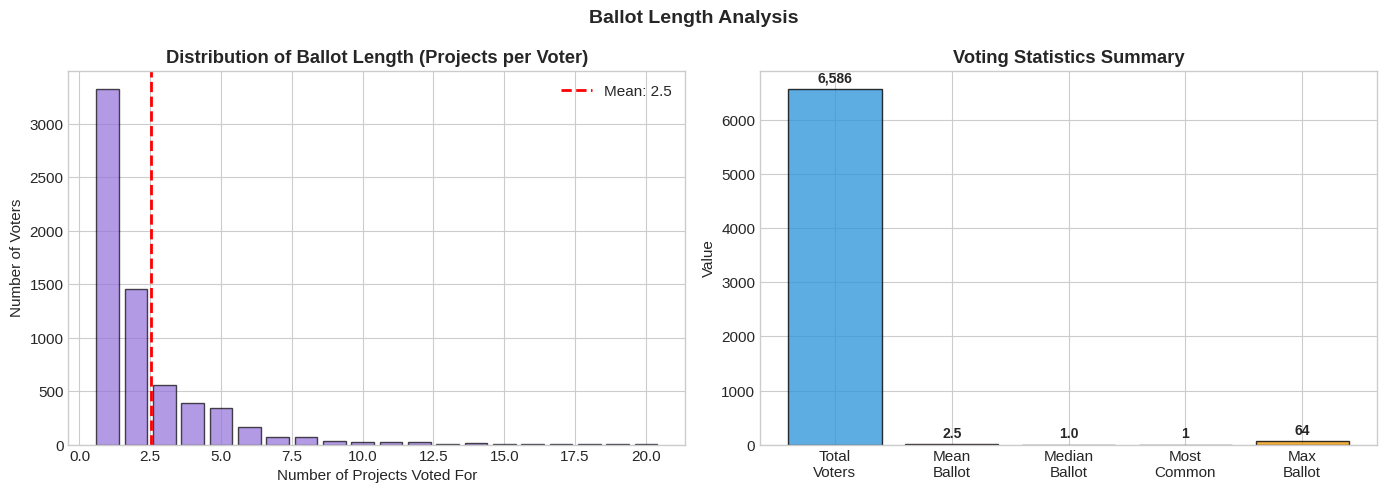

In [ ]:
# How many projects did each voter vote for? - Visualize fully
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vote_counts = votes_df['num_projects'].value_counts().sort_index()

# 1. Bar chart of ballot lengths
axes[0].bar(vote_counts.index[:20], vote_counts.values[:20], edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0].set_xlabel('Number of Projects Voted For')
axes[0].set_ylabel('Number of Voters')
axes[0].set_title('Distribution of Ballot Length (Projects per Voter)', fontweight='bold')

mean_votes = votes_df['num_projects'].mean()
axes[0].axvline(mean_votes, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_votes:.1f}')
axes[0].legend()

# 2. Summary statistics as visual
stats_labels = ['Total\nVoters', 'Mean\nBallot', 'Median\nBallot', 'Most\nCommon', 'Max\nBallot']
stats_values = [len(votes_df), mean_votes, votes_df['num_projects'].median(),
                vote_counts.idxmax(), votes_df['num_projects'].max()]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

bars = axes[1].bar(stats_labels, stats_values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Value')
axes[1].set_title('Voting Statistics Summary', fontweight='bold')

for bar, val in zip(bars, stats_values):
    if isinstance(val, float):
        label = f'{val:.1f}'
    else:
        label = f'{val:,}' if val > 100 else str(val)
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stats_values)*0.02,
                 label, ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Ballot Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Method of Equal Shares - Implementation and Analysis

Now let's implement the Method of Equal Shares algorithm. The basic idea is:

1. Give each voter an equal share of the budget: `budget / num_voters`
2. While there are affordable projects:
   - For each project, calculate if supporters can afford it (cost / num_supporters <= remaining budget of each supporter)
   - Select the project with the highest "effective vote count" that's affordable
   - Deduct the cost equally from all supporters' budgets
3. The algorithm might not spend the entire budget (this is where Add1 comes in!)

In [ ]:
def method_of_equal_shares(projects, votes, budget, num_voters):
    """
    Implementation of the Method of Equal Shares.

    This is a simplified version - the real implementation has some
    more complex tie-breaking rules, but this should give us a good idea.
    """
    # Initialize voter budgets - everyone gets an equal share
    initial_budget_per_voter = budget / num_voters
    voter_budgets = {v['voter_id']: initial_budget_per_voter for v in votes}

    # Create a mapping of project_id to supporters
    project_supporters = defaultdict(set)
    for vote in votes:
        for proj_id in vote['projects_voted']:
            project_supporters[proj_id].add(vote['voter_id'])

    # Track which projects are available and selected
    available_projects = {p['project_id']: int(p['cost']) for p in projects}
    selected_projects = []
    total_spent = 0

    iteration = 0
    iteration_log = []

    while available_projects:
        iteration += 1
        best_project = None
        best_score = -1
        best_cost_per_voter = float('inf')

        for proj_id, cost in available_projects.items():
            supporters = project_supporters[proj_id]
            if not supporters:
                continue

            # Calculate how much each supporter would need to pay
            # We need to find the minimum payment such that it's affordable
            supporter_budgets = [voter_budgets[s] for s in supporters if s in voter_budgets]

            if not supporter_budgets:
                continue

            # Sort budgets to find affordable payment
            sorted_budgets = sorted(supporter_budgets, reverse=True)

            # Check if project is affordable
            affordable = False
            cost_per_voter = cost / len(sorted_budgets)

            # More sophisticated check: find the max payment everyone can afford
            remaining_cost = cost
            contributors = 0
            for b in sorted_budgets:
                if contributors == 0:
                    cost_per_voter = remaining_cost / (len(sorted_budgets) - contributors)
                else:
                    cost_per_voter = remaining_cost / (len(sorted_budgets) - contributors)

                if b >= cost_per_voter:
                    affordable = True
                    break
                else:
                    remaining_cost -= b
                    contributors += 1

            if affordable and len(supporters) > best_score:
                best_score = len(supporters)
                best_project = proj_id
                best_cost_per_voter = cost_per_voter

        if best_project is None:
            # No more affordable projects
            break

        # Select the best project
        cost = available_projects[best_project]
        supporters = project_supporters[best_project]

        # Deduct from supporter budgets (simplified: equal split)
        active_supporters = [s for s in supporters if voter_budgets.get(s, 0) > 0]
        if active_supporters:
            payment = cost / len(active_supporters)
            for supporter in active_supporters:
                voter_budgets[supporter] = max(0, voter_budgets[supporter] - payment)

        selected_projects.append(best_project)
        total_spent += cost
        del available_projects[best_project]

        iteration_log.append({
            'iteration': iteration,
            'project_id': best_project,
            'cost': cost,
            'supporters': len(supporters),
            'total_spent': total_spent
        })

        # Check if we've exceeded budget
        if total_spent >= budget:
            break

    return selected_projects, total_spent, iteration_log, voter_budgets

print("MES implementation ready!")

MES implementation ready!


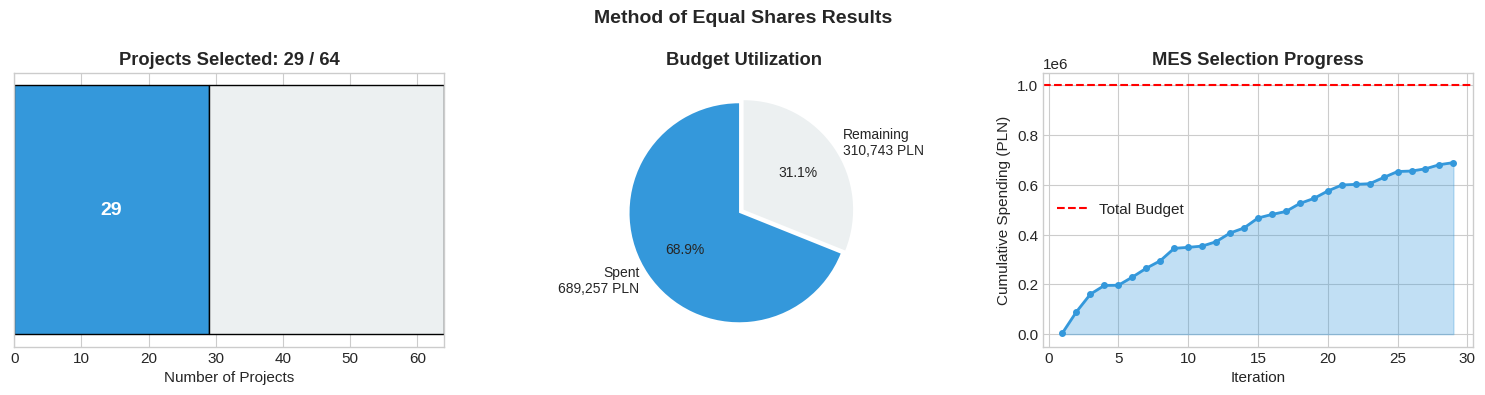

In [ ]:
# Run MES on our data
budget = int(metadata['budget'])
num_voters = int(metadata['num_votes'])

mes_selected, mes_spent, mes_log, remaining_budgets = method_of_equal_shares(
    projects_raw, votes_data, budget, num_voters
)

# Visualize MES results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Projects selected gauge
axes[0].barh([''], [len(mes_selected)], color='#3498db', edgecolor='black', height=0.4)
axes[0].barh([''], [len(projects_df) - len(mes_selected)], left=[len(mes_selected)],
             color='#ecf0f1', edgecolor='black', height=0.4)
axes[0].set_xlim(0, len(projects_df))
axes[0].set_xlabel('Number of Projects')
axes[0].set_title(f'Projects Selected: {len(mes_selected)} / {len(projects_df)}', fontweight='bold')
axes[0].text(len(mes_selected)/2, 0, f'{len(mes_selected)}', ha='center', va='center',
             fontsize=14, fontweight='bold', color='white')

# 2. Budget utilization pie
axes[1].pie([mes_spent, budget - mes_spent],
            labels=[f'Spent\n{mes_spent:,} PLN', f'Remaining\n{budget-mes_spent:,} PLN'],
            colors=['#3498db', '#ecf0f1'], autopct='%1.1f%%', startangle=90,
            explode=[0.05, 0], textprops={'fontsize': 10})
axes[1].set_title('Budget Utilization', fontweight='bold')

# 3. Selection progress over iterations
if mes_log:
    iterations = [log['iteration'] for log in mes_log]
    cumulative_spent = [log['total_spent'] for log in mes_log]
    axes[2].fill_between(iterations, cumulative_spent, alpha=0.3, color='#3498db')
    axes[2].plot(iterations, cumulative_spent, 'o-', color='#3498db', linewidth=2, markersize=4)
    axes[2].axhline(y=budget, color='red', linestyle='--', label='Total Budget')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Cumulative Spending (PLN)')
    axes[2].set_title('MES Selection Progress', fontweight='bold')
    axes[2].legend()

plt.suptitle('Method of Equal Shares Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Show the selection order
mes_log_df = pd.DataFrame(mes_log)

# Add project names
project_names = {p['project_id']: p['name'][:50] + '...' if len(p['name']) > 50 else p['name']
                 for p in projects_raw}
mes_log_df['project_name'] = mes_log_df['project_id'].map(project_names)

print("MES Selection Order:")
mes_log_df

MES Selection Order:


,iteration,project_id,cost,supporters,total_spent,project_name
0,1,24,5000,720,5000,Zakup 10 fotopułapek przeciwko śmieciarzom i d...
1,2,41,85000,658,90000,Stworzenie warunków rekreacyjnych dla mieszkań...
2,3,74,70800,552,160800,Rewitalizacja zieleni parku przy kościele św. ...
3,4,32,34999,428,195799,Nasadzenie drzew krzewów i traw przy nowo budo...
4,5,39,600,418,196399,Budki lęgowe dla jerzyków
5,6,58,32716,400,229115,Zielony skwerek przy Szkole Podstawowej im. Kr...
6,7,42,35720,388,264835,Rewitalizacja zieleni na działce nr 484/4 przy...
7,8,25,30000,379,294835,Eko KROKusy
8,9,16,50000,376,344835,Zielony Mi(lion)etniów - zielona lekcja
9,10,43,3969,372,348804,Kosze na śmieci w Węgrzcach Wielkich


## 5. Add1 Completion Method

The Method of Equal Shares often doesn't spend the entire budget because it's very "careful" about fairness. The **Add1 completion** is a way to spend the remaining budget.

The idea is simple:
1. After MES finishes, we have some unspent budget
2. We use a greedy method to select additional projects that fit in the remaining budget
3. Projects are selected by their vote count (most popular first)

This combines the fairness of MES with the efficiency of greedy methods!

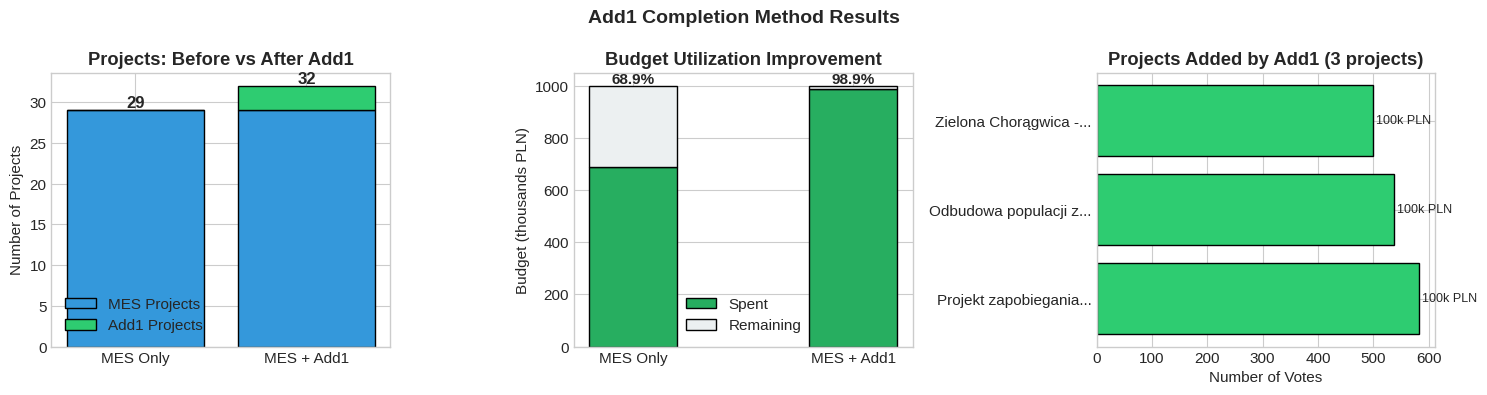

In [ ]:
def add1_completion(projects, mes_selected, budget, total_spent):
    """
    Add1 completion method - greedily add projects after MES
    to maximize budget utilization.

    Projects are sorted by vote count and added if they fit.
    """
    remaining_budget = budget - total_spent
    selected_set = set(mes_selected)

    # Get available projects sorted by votes (descending)
    available = [(p['project_id'], int(p['cost']), int(p['votes']))
                 for p in projects
                 if p['project_id'] not in selected_set]
    available.sort(key=lambda x: x[2], reverse=True)  # Sort by votes

    add1_selected = []
    add1_spent = 0

    for proj_id, cost, votes in available:
        if cost <= remaining_budget:
            add1_selected.append({
                'project_id': proj_id,
                'cost': cost,
                'votes': votes
            })
            remaining_budget -= cost
            add1_spent += cost

    return add1_selected, add1_spent, remaining_budget

# Run Add1 completion
add1_selected, add1_spent, final_remaining = add1_completion(
    projects_raw, mes_selected, budget, mes_spent
)

# Visualize Add1 completion results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Before vs After Add1 (stacked bar)
x = ['MES Only', 'MES + Add1']
mes_projects = [len(mes_selected), len(mes_selected)]
add1_projects = [0, len(add1_selected)]

axes[0].bar(x, mes_projects, label='MES Projects', color='#3498db', edgecolor='black')
axes[0].bar(x, add1_projects, bottom=mes_projects, label='Add1 Projects', color='#2ecc71', edgecolor='black')
axes[0].set_ylabel('Number of Projects')
axes[0].set_title('Projects: Before vs After Add1', fontweight='bold')
axes[0].legend()
for i, (m, a) in enumerate(zip(mes_projects, add1_projects)):
    axes[0].text(i, m + a + 0.3, f'{m+a}', ha='center', fontsize=12, fontweight='bold')

# 2. Budget utilization comparison
spent_before = [mes_spent, mes_spent + add1_spent]
remaining_before = [budget - mes_spent, final_remaining]

x_pos = np.arange(2)
width = 0.4
axes[1].bar(x_pos, [s/1000 for s in spent_before], width, label='Spent', color='#27ae60', edgecolor='black')
axes[1].bar(x_pos, [r/1000 for r in remaining_before], width, bottom=[s/1000 for s in spent_before],
            label='Remaining', color='#ecf0f1', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['MES Only', 'MES + Add1'])
axes[1].set_ylabel('Budget (thousands PLN)')
axes[1].set_title('Budget Utilization Improvement', fontweight='bold')
axes[1].legend()
for i, (s, total) in enumerate(zip(spent_before, [budget, budget])):
    axes[1].text(i, total/1000 + 10, f'{s/budget*100:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 3. Add1 selected projects (if any)
if add1_selected:
    add1_df = pd.DataFrame(add1_selected)
    add1_df['short_name'] = add1_df['project_id'].map(
        {p['project_id']: p['name'][:20] + '...' for p in projects_raw})

    bars = axes[2].barh(add1_df['short_name'], add1_df['votes'], color='#2ecc71', edgecolor='black')
    axes[2].set_xlabel('Number of Votes')
    axes[2].set_title(f'Projects Added by Add1 ({len(add1_selected)} projects)', fontweight='bold')
    for bar, cost in zip(bars, add1_df['cost']):
        axes[2].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                     f'{cost/1000:.0f}k PLN', va='center', fontsize=9)
else:
    axes[2].text(0.5, 0.5, 'No projects added\n(MES used most budget)',
                 ha='center', va='center', fontsize=12, transform=axes[2].transAxes)
    axes[2].set_title('Add1 Projects', fontweight='bold')

plt.suptitle('Add1 Completion Method Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

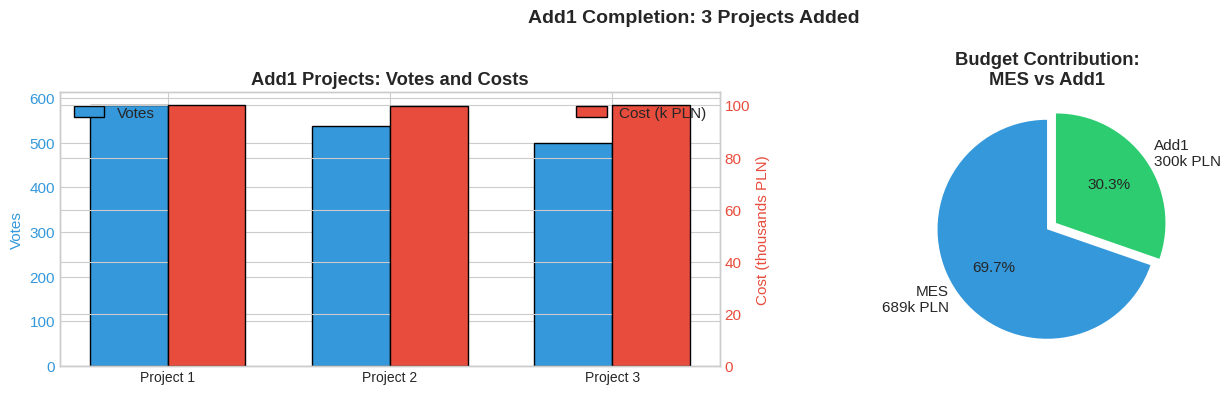

In [ ]:
# Visualize Add1 selected projects details
if add1_selected:
    add1_df = pd.DataFrame(add1_selected)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # 1. Projects added with their votes and costs
    short_names = [projects_raw[i]['name'][:25] + '...'
                   for i, p in enumerate(projects_raw)
                   if p['project_id'] in add1_df['project_id'].values][:len(add1_df)]

    # Use project names from the mapping
    add1_df['short_name'] = add1_df['project_id'].map(
        {p['project_id']: p['name'][:25] + '...' for p in projects_raw})

    x = np.arange(len(add1_df))
    width = 0.35

    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, add1_df['votes'], width, label='Votes', color='#3498db', edgecolor='black')
    ax1.set_ylabel('Votes', color='#3498db')
    ax1.tick_params(axis='y', labelcolor='#3498db')

    ax1_twin = ax1.twinx()
    bars2 = ax1_twin.bar(x + width/2, add1_df['cost']/1000, width, label='Cost (k PLN)', color='#e74c3c', edgecolor='black')
    ax1_twin.set_ylabel('Cost (thousands PLN)', color='#e74c3c')
    ax1_twin.tick_params(axis='y', labelcolor='#e74c3c')

    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Project {i+1}' for i in range(len(add1_df))], fontsize=10)
    ax1.set_title('Add1 Projects: Votes and Costs', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')

    # 2. Pie chart of Add1 contribution
    axes[1].pie([mes_spent, add1_spent],
                labels=[f'MES\n{mes_spent/1000:.0f}k PLN', f'Add1\n{add1_spent/1000:.0f}k PLN'],
                colors=['#3498db', '#2ecc71'], autopct='%1.1f%%', startangle=90,
                explode=[0, 0.1], textprops={'fontsize': 11})
    axes[1].set_title('Budget Contribution:\nMES vs Add1', fontweight='bold')

    plt.suptitle(f'Add1 Completion: {len(add1_selected)} Projects Added', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.text(0.5, 0.5, 'No projects added by Add1\n(MES already spent most of budget)',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.axis('off')
    ax.set_title('Add1 Completion Results', fontweight='bold')
    plt.show()

## 6. Comparison of All Voting Methods

Now let's compare all voting methods:
- **MES (Method of Equal Shares)**: Proportional, budget-based
- **MES + Add1**: MES with greedy completion for remaining budget
- **Phragmén's Sequential Method**: Minimizes maximum voter load
- **SPAV (Sequential Proportional Approval)**: Reweights votes after selections
- **Greedy Approval**: Simple popularity-based (baseline)


In [ ]:
def greedy_approval(projects, budget):
    """
    Simple greedy algorithm - select most popular projects that fit in budget.
    This is basically what most PB elections used before MES!
    """
    sorted_projects = sorted(projects, key=lambda x: int(x['votes']), reverse=True)

    selected = []
    total_spent = 0

    for p in sorted_projects:
        cost = int(p['cost'])
        if total_spent + cost <= budget:
            selected.append(p['project_id'])
            total_spent += cost

    return selected, total_spent

greedy_selected, greedy_spent = greedy_approval(projects_raw, budget)
print(f"Greedy method selected {len(greedy_selected)} projects, spent {greedy_spent:,} PLN")


Greedy method selected 23 projects, spent 998,997 PLN


In [ ]:
def phragmen_sequential(projects, votes, budget, num_voters):
    """
    Phragmén's Sequential Method adapted for Participatory Budgeting.

    The idea: each voter has a 'load' that increases when projects they support
    are selected. We select projects that minimize the maximum load increase.

    For PB, load increase = project_cost / number_of_supporters
    """
    # Initialize voter loads to 0
    voter_loads = {v['voter_id']: 0.0 for v in votes}

    # Create mapping of project_id to supporters
    project_supporters = defaultdict(set)
    for vote in votes:
        for proj_id in vote['projects_voted']:
            project_supporters[proj_id].add(vote['voter_id'])

    # Available projects
    available_projects = {p['project_id']: int(p['cost']) for p in projects}
    selected_projects = []
    total_spent = 0
    iteration_log = []

    while available_projects:
        best_project = None
        best_max_load = float('inf')

        for proj_id, cost in available_projects.items():
            supporters = project_supporters[proj_id]
            if not supporters:
                continue

            # Check if project fits in remaining budget
            if total_spent + cost > budget:
                continue

            # Calculate the load increase for each supporter
            load_per_supporter = cost / len(supporters)

            # Find the maximum load after adding this project
            max_load_after = max(
                voter_loads[s] + load_per_supporter
                for s in supporters
            )

            # Select project that minimizes maximum load
            if max_load_after < best_max_load:
                best_max_load = max_load_after
                best_project = proj_id

        if best_project is None:
            break

        # Select the best project
        cost = available_projects[best_project]
        supporters = project_supporters[best_project]
        load_per_supporter = cost / len(supporters)

        # Update voter loads
        for s in supporters:
            voter_loads[s] += load_per_supporter

        selected_projects.append(best_project)
        total_spent += cost
        del available_projects[best_project]

        iteration_log.append({
            'iteration': len(selected_projects),
            'project_id': best_project,
            'cost': cost,
            'supporters': len(supporters),
            'max_load': best_max_load,
            'total_spent': total_spent
        })

    return selected_projects, total_spent, iteration_log, voter_loads

print("Phragmén's Sequential Method implementation ready!")

Phragmén's Sequential Method implementation ready!


In [ ]:
def sequential_pav(projects, votes, budget, num_voters):
    """
    Sequential Proportional Approval Voting (SPAV) for PB.

    After selecting a project, voters who supported it get their
    voting weight reduced. Weight = 1 / (1 + projects_won)

    This makes it harder for already-satisfied voters to dominate.
    """
    # Initialize voter weights to 1
    voter_weights = {v['voter_id']: 1.0 for v in votes}
    voter_wins = {v['voter_id']: 0 for v in votes}  # Track wins per voter

    # Create mapping of project_id to supporters
    project_supporters = defaultdict(set)
    for vote in votes:
        for proj_id in vote['projects_voted']:
            project_supporters[proj_id].add(vote['voter_id'])

    available_projects = {p['project_id']: int(p['cost']) for p in projects}
    selected_projects = []
    total_spent = 0
    iteration_log = []

    while available_projects:
        best_project = None
        best_score = -1

        for proj_id, cost in available_projects.items():
            supporters = project_supporters[proj_id]
            if not supporters:
                continue

            # Check budget constraint
            if total_spent + cost > budget:
                continue

            # Calculate weighted score (sum of supporter weights)
            weighted_score = sum(voter_weights[s] for s in supporters)

            if weighted_score > best_score:
                best_score = weighted_score
                best_project = proj_id

        if best_project is None:
            break

        # Select the best project
        cost = available_projects[best_project]
        supporters = project_supporters[best_project]

        # Update voter weights using d'Hondt divisors: 1/(1+k)
        for s in supporters:
            voter_wins[s] += 1
            voter_weights[s] = 1.0 / (1 + voter_wins[s])

        selected_projects.append(best_project)
        total_spent += cost
        del available_projects[best_project]

        iteration_log.append({
            'iteration': len(selected_projects),
            'project_id': best_project,
            'cost': cost,
            'supporters': len(supporters),
            'weighted_score': best_score,
            'total_spent': total_spent
        })

    return selected_projects, total_spent, iteration_log, voter_weights

print("Sequential PAV implementation ready!")

Sequential PAV implementation ready!


In [ ]:
# Run Phragmén's method
phragmen_selected, phragmen_spent, phragmen_log, phragmen_loads = phragmen_sequential(
    projects_raw, votes_data, budget, num_voters
)

# Run SPAV
spav_selected, spav_spent, spav_log, spav_weights = sequential_pav(
    projects_raw, votes_data, budget, num_voters
)

print(f"Results Summary:")
print(f"="*50)
print(f"{'Method':<20} {'Projects':<12} {'Budget Spent':<15} {'Utilization'}")
print(f"{'-'*50}")
print(f"{'MES':<20} {len(mes_selected):<12} {mes_spent:>12,} PLN  {mes_spent/budget*100:.1f}%")
print(f"{'MES + Add1':<20} {len(mes_selected)+len(add1_selected):<12} {mes_spent+add1_spent:>12,} PLN  {(mes_spent+add1_spent)/budget*100:.1f}%")
print(f"{'Phragmén':<20} {len(phragmen_selected):<12} {phragmen_spent:>12,} PLN  {phragmen_spent/budget*100:.1f}%")
print(f"{'SPAV':<20} {len(spav_selected):<12} {spav_spent:>12,} PLN  {spav_spent/budget*100:.1f}%")
print(f"{'Greedy':<20} {len(greedy_selected):<12} {greedy_spent:>12,} PLN  {greedy_spent/budget*100:.1f}%")

Results Summary:
Method               Projects     Budget Spent    Utilization
--------------------------------------------------
MES                  29                689,257 PLN  68.9%
MES + Add1           32                989,057 PLN  98.9%
Phragmén             33                975,057 PLN  97.5%
SPAV                 25                997,556 PLN  99.8%
Greedy               23                998,997 PLN  99.9%


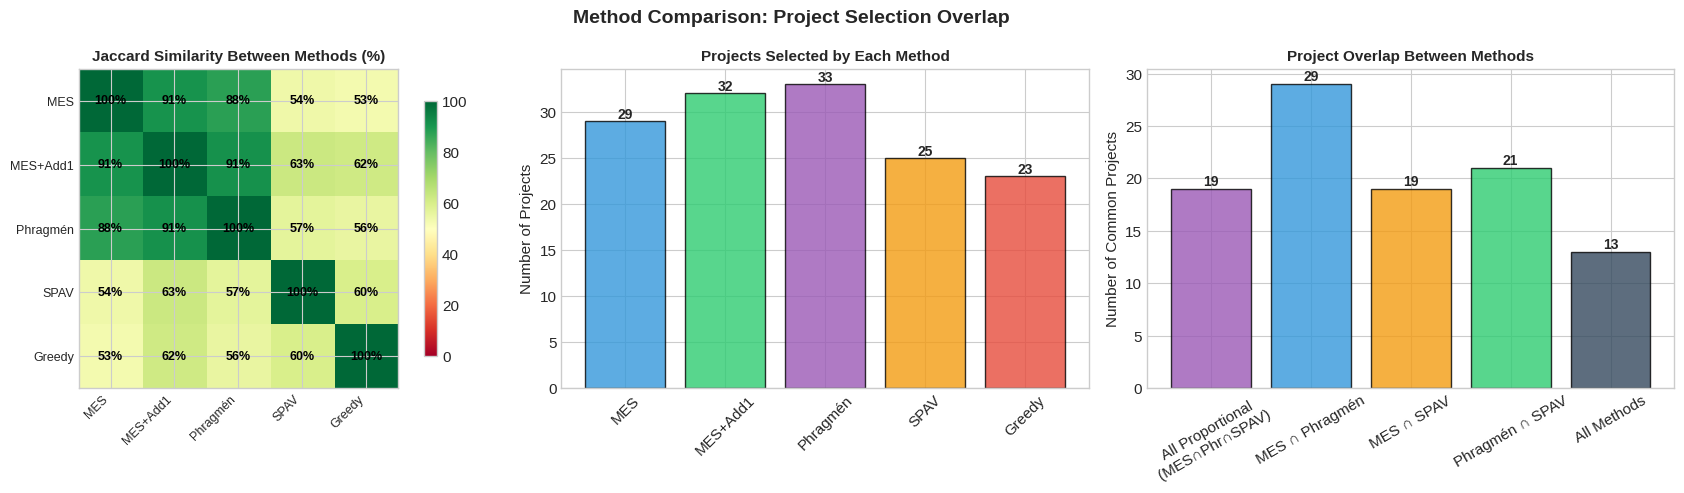

In [ ]:
# Visualize overlap between all methods using heatmaps and bar charts
mes_add1_combined = set(mes_selected + [p['project_id'] for p in add1_selected])
mes_only_set = set(mes_selected)
greedy_set = set(greedy_selected)
phragmen_set = set(phragmen_selected)
spav_set = set(spav_selected)

# All method sets
methods_all = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
sets_all = [mes_only_set, mes_add1_combined, phragmen_set, spav_set, greedy_set]
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

# Create Jaccard similarity matrix
jaccard_matrix = np.zeros((5, 5))
for i, set1 in enumerate(sets_all):
    for j, set2 in enumerate(sets_all):
        if len(set1 | set2) > 0:
            jaccard_matrix[i, j] = len(set1 & set2) / len(set1 | set2) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Jaccard Similarity Heatmap
im = axes[0].imshow(jaccard_matrix, cmap='RdYlGn', vmin=0, vmax=100)
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))
axes[0].set_xticklabels(methods_all, fontsize=9, rotation=45, ha='right')
axes[0].set_yticklabels(methods_all, fontsize=9)
axes[0].set_title('Jaccard Similarity Between Methods (%)', fontsize=11, fontweight='bold')

for i in range(5):
    for j in range(5):
        text_color = 'white' if jaccard_matrix[i, j] < 50 else 'black'
        axes[0].text(j, i, f'{jaccard_matrix[i, j]:.0f}%',
                    ha='center', va='center', color=text_color, fontsize=9, fontweight='bold')

plt.colorbar(im, ax=axes[0], shrink=0.8)

# 2. Project counts per method
project_counts = [len(s) for s in sets_all]
bars = axes[1].bar(methods_all, project_counts, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Number of Projects')
axes[1].set_title('Projects Selected by Each Method', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, project_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(count), ha='center', fontsize=10, fontweight='bold')

# 3. Common projects across proportional methods
proportional_common = mes_only_set & phragmen_set & spav_set
all_common = mes_only_set & phragmen_set & spav_set & greedy_set

overlap_data = {
    'All Proportional\n(MES∩Phr∩SPAV)': len(proportional_common),
    'MES ∩ Phragmén': len(mes_only_set & phragmen_set),
    'MES ∩ SPAV': len(mes_only_set & spav_set),
    'Phragmén ∩ SPAV': len(phragmen_set & spav_set),
    'All Methods': len(all_common)
}

bars = axes[2].bar(overlap_data.keys(), overlap_data.values(),
                   color=['#9b59b6', '#3498db', '#f39c12', '#2ecc71', '#34495e'],
                   edgecolor='black', alpha=0.8)
axes[2].set_ylabel('Number of Common Projects')
axes[2].set_title('Project Overlap Between Methods', fontsize=11, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Method Comparison: Project Selection Overlap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


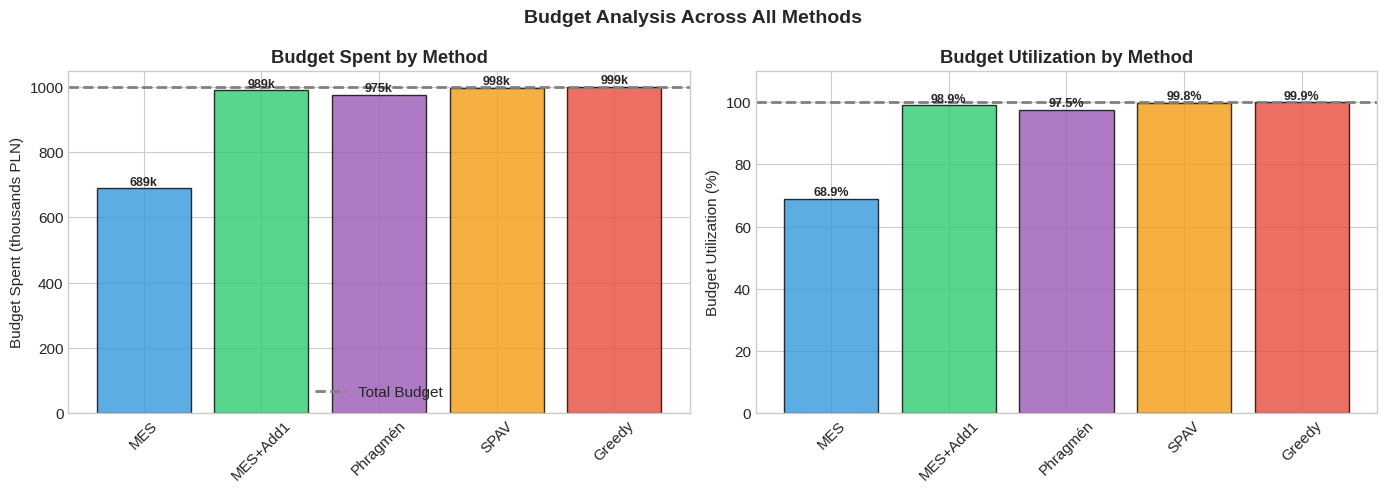

In [ ]:
# Visualize budget utilization and method comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

mes_add1_spent = mes_spent + add1_spent
spent_amounts = [mes_spent, mes_add1_spent, phragmen_spent, spav_spent, greedy_spent]
project_counts = [len(mes_selected), len(mes_selected)+len(add1_selected),
                  len(phragmen_selected), len(spav_selected), len(greedy_selected)]

# 1. Budget spent
bars1 = axes[0].bar(methods, [s/1000 for s in spent_amounts], color=colors, edgecolor='black', alpha=0.8)
axes[0].axhline(y=budget/1000, color='gray', linestyle='--', linewidth=2, label='Total Budget')
axes[0].set_ylabel('Budget Spent (thousands PLN)')
axes[0].set_title('Budget Spent by Method', fontweight='bold')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)
for bar, amt in zip(bars1, spent_amounts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{amt/1000:.0f}k', ha='center', fontsize=9, fontweight='bold')

# 2. Budget utilization percentage
utilization = [s/budget*100 for s in spent_amounts]
bars2 = axes[1].bar(methods, utilization, color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(y=100, color='gray', linestyle='--', linewidth=2)
axes[1].set_ylabel('Budget Utilization (%)')
axes[1].set_title('Budget Utilization by Method', fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=45)
for bar, util in zip(bars2, utilization):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{util:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Budget Analysis Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Fairness Analysis

One of the main selling points of MES is that it's more fair than greedy methods. Let's analyze voter satisfaction to see if this is true for our dataset.

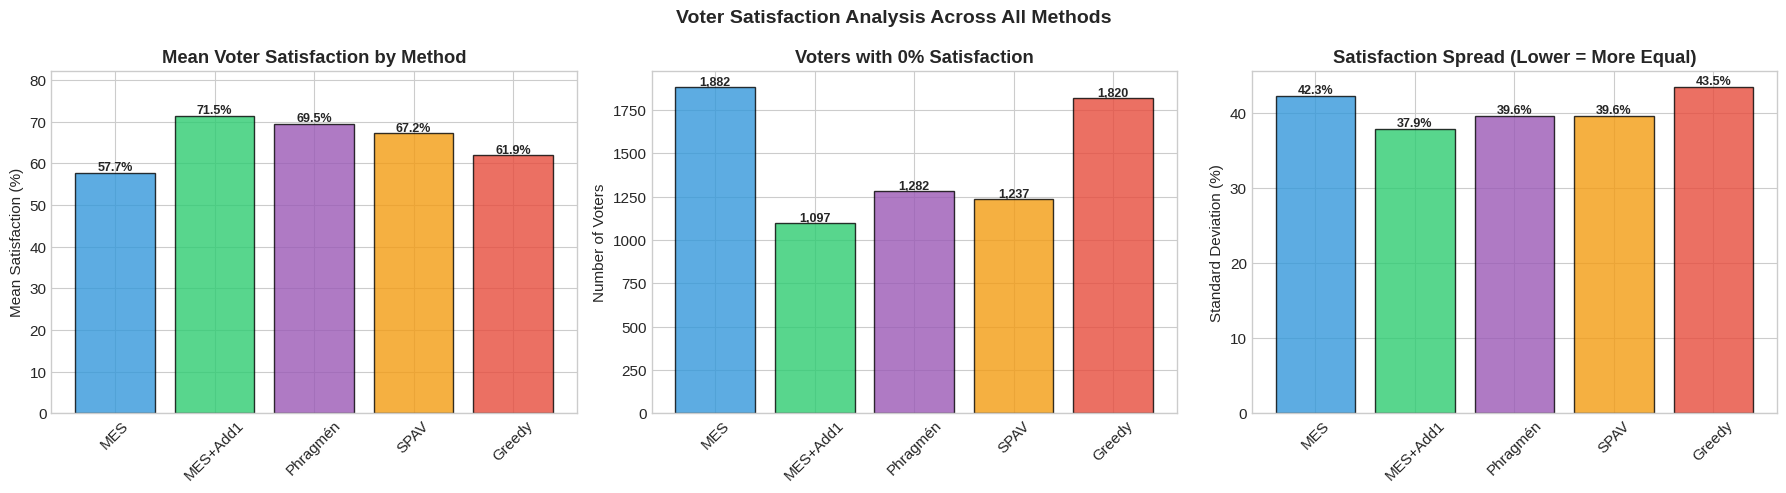

In [ ]:
def calculate_voter_satisfaction(votes_data, selected_projects):
    """
    Calculate how many of each voter's preferred projects were selected.
    Returns a list of satisfaction scores (fraction of voted projects that were selected)
    """
    selected_set = set(selected_projects)
    satisfaction_scores = []

    for vote in votes_data:
        voted_projects = set(vote['projects_voted'])
        if len(voted_projects) == 0:
            continue
        selected_from_vote = voted_projects & selected_set
        satisfaction = len(selected_from_vote) / len(voted_projects)
        satisfaction_scores.append(satisfaction)

    return satisfaction_scores

# Calculate satisfaction for all methods
sat_mes = calculate_voter_satisfaction(votes_data, mes_selected)
sat_mes_add1 = calculate_voter_satisfaction(votes_data, list(mes_add1_combined))
sat_phragmen = calculate_voter_satisfaction(votes_data, phragmen_selected)
sat_spav = calculate_voter_satisfaction(votes_data, spav_selected)
sat_greedy = calculate_voter_satisfaction(votes_data, greedy_selected)

# Visualize voter satisfaction metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]

# 1. Mean satisfaction comparison
mean_sats = [np.mean(s)*100 for s in sat_data]
bars1 = axes[0].bar(methods, mean_sats, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Mean Satisfaction (%)')
axes[0].set_title('Mean Voter Satisfaction by Method', fontweight='bold')
axes[0].set_ylim(0, max(mean_sats) * 1.15)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, mean_sats):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 2. Voters with zero satisfaction
zero_sats = [sum(1 for s in sat if s == 0) for sat in sat_data]
bars2 = axes[1].bar(methods, zero_sats, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Number of Voters')
axes[1].set_title('Voters with 0% Satisfaction', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, zero_sats):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# 3. Standard deviation (fairness measure)
std_sats = [np.std(s)*100 for s in sat_data]
bars3 = axes[2].bar(methods, std_sats, color=colors, edgecolor='black', alpha=0.8)
axes[2].set_ylabel('Standard Deviation (%)')
axes[2].set_title('Satisfaction Spread (Lower = More Equal)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, std_sats):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Voter Satisfaction Analysis Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


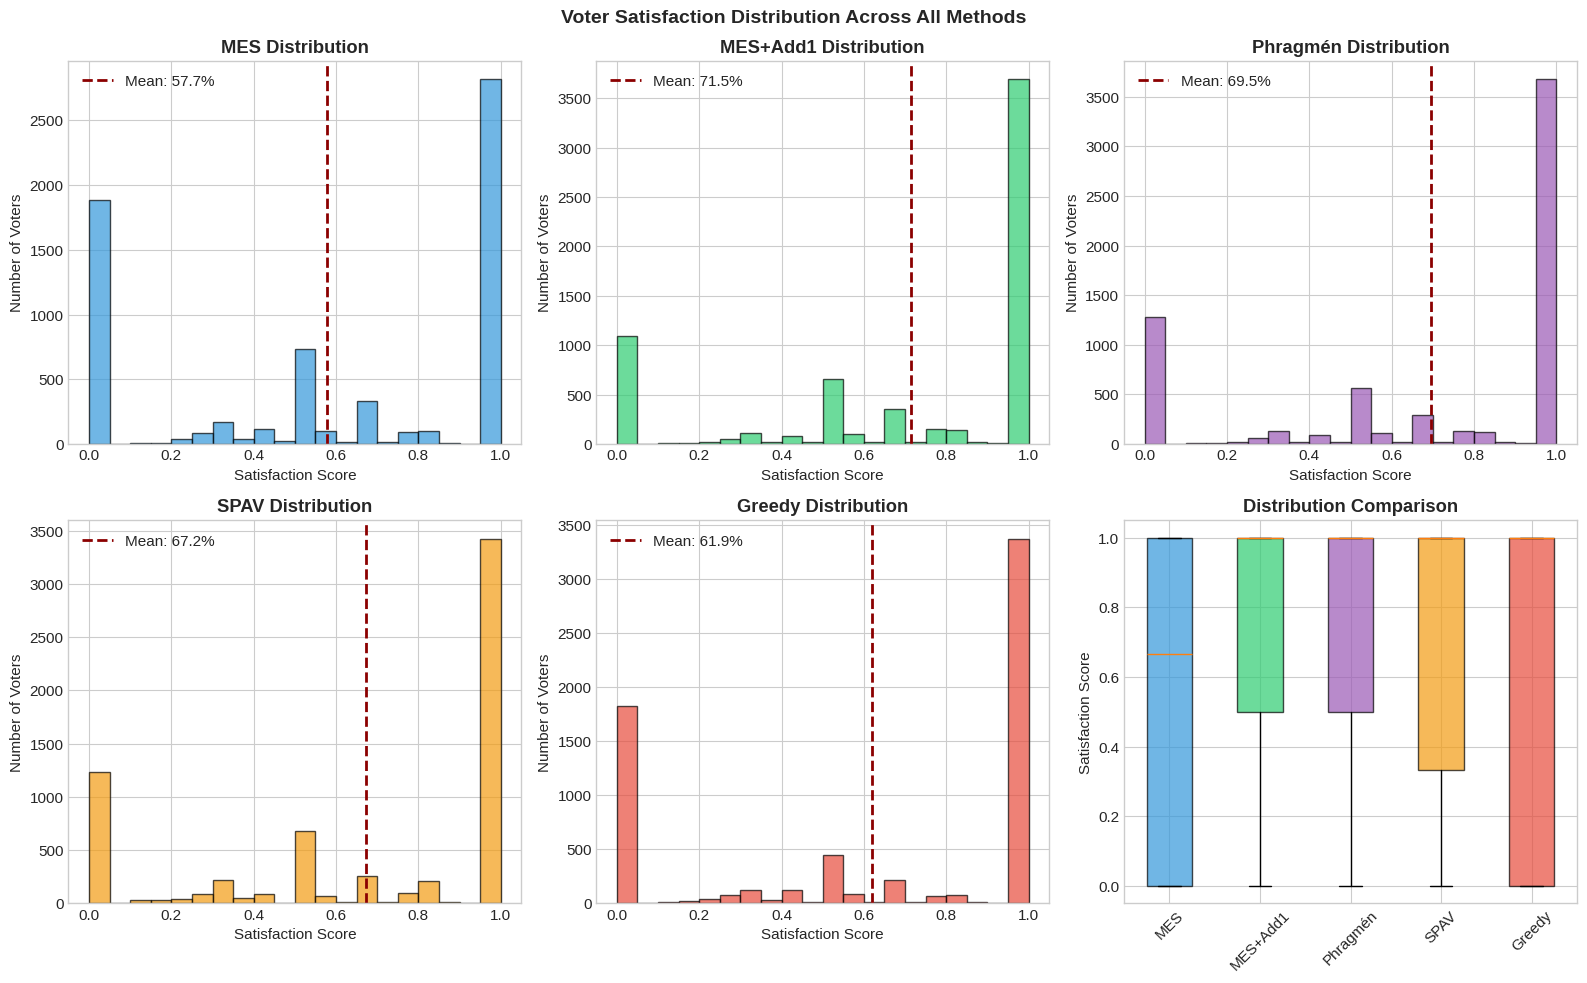

In [ ]:
# Visualize satisfaction distributions for all methods
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]

# Histograms for each method
for i, (method, sat, color) in enumerate(zip(methods, sat_data, colors)):
    row, col = i // 3, i % 3
    axes[row, col].hist(sat, bins=20, alpha=0.7, color=color, edgecolor='black')
    axes[row, col].axvline(np.mean(sat), color='darkred', linestyle='--', linewidth=2,
                           label=f'Mean: {np.mean(sat)*100:.1f}%')
    axes[row, col].set_xlabel('Satisfaction Score')
    axes[row, col].set_ylabel('Number of Voters')
    axes[row, col].set_title(f'{method} Distribution', fontweight='bold')
    axes[row, col].legend()

# Box plot comparison in the 6th subplot
bp = axes[1, 2].boxplot(sat_data, labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 2].set_ylabel('Satisfaction Score')
axes[1, 2].set_title('Distribution Comparison', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Voter Satisfaction Distribution Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


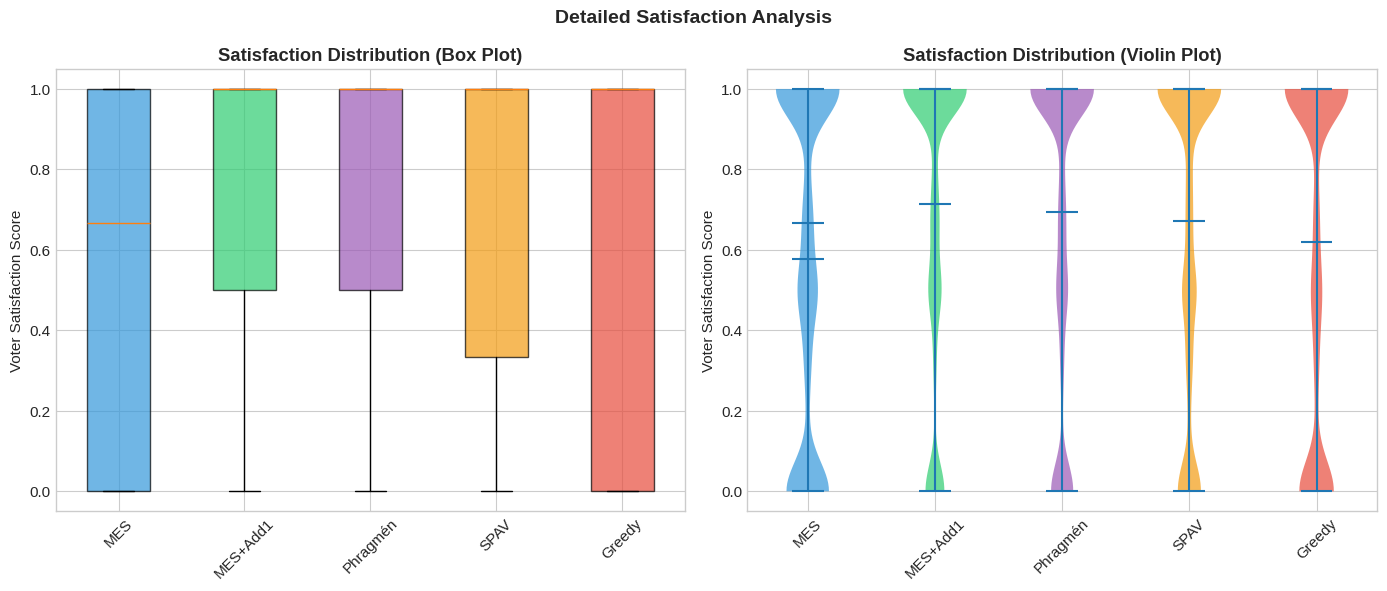

In [ ]:
# Detailed box plot comparison with violin overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]

# 1. Box plot
bp = axes[0].boxplot(sat_data, labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Voter Satisfaction Score')
axes[0].set_title('Satisfaction Distribution (Box Plot)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 2. Violin plot for more detail
vp = axes[1].violinplot(sat_data, positions=range(len(methods)), showmeans=True, showmedians=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)
axes[1].set_xticks(range(len(methods)))
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('Voter Satisfaction Score')
axes[1].set_title('Satisfaction Distribution (Violin Plot)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Detailed Satisfaction Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.1 Proportionality Analysis: Gini Coefficient & Lorenz Curve

The **Gini coefficient** measures inequality - a value of 0 means perfect equality (everyone gets the same), while 1 means maximum inequality. For participatory budgeting, MES should produce a lower Gini (more equal distribution of satisfaction) than Greedy.

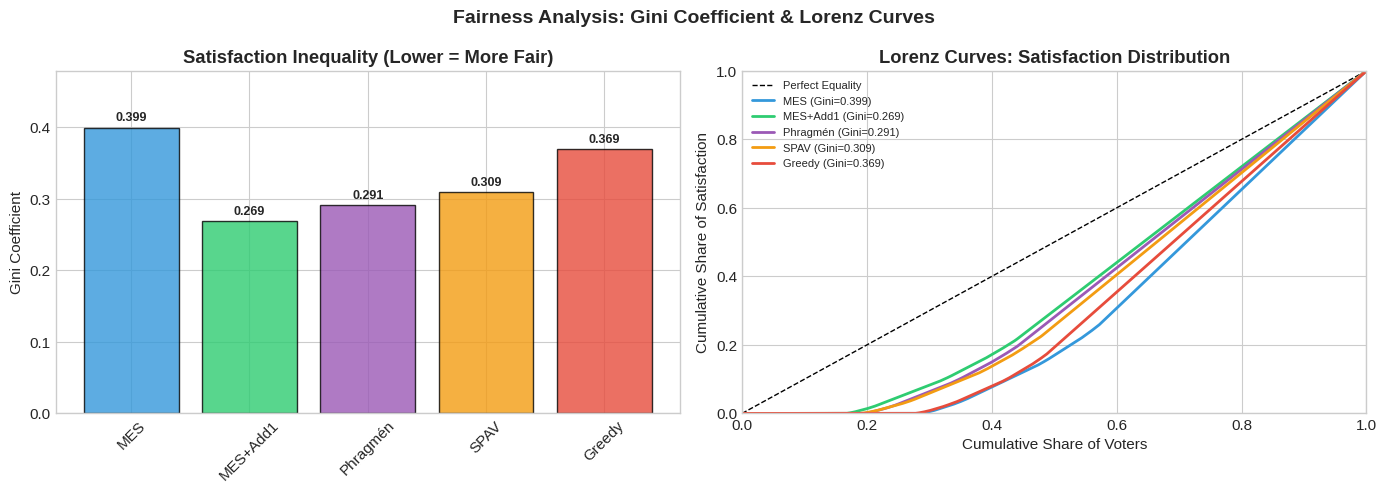

In [ ]:
# Define mes_add1_selected as a list for the analysis below
mes_add1_selected = list(mes_add1_combined)

# Calculate Gini coefficient for fairness comparison
def gini_coefficient(values):
    """Calculate Gini coefficient - 0 means perfect equality, 1 means maximum inequality"""
    sorted_values = np.sort(values)
    n = len(sorted_values)
    cumsum = np.cumsum(sorted_values)
    return (2 * np.sum((np.arange(1, n+1) * sorted_values)) - (n + 1) * np.sum(sorted_values)) / (n * np.sum(sorted_values))

def lorenz_curve(values):
    """Calculate Lorenz curve points"""
    sorted_values = np.sort(values)
    cumsum = np.cumsum(sorted_values)
    return np.insert(cumsum / cumsum[-1], 0, 0)

# Calculate Gini for all methods
methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]
ginis = [gini_coefficient(s) for s in sat_data]

# Visualize Gini and Lorenz curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gini coefficient comparison
bars = axes[0].bar(methods, ginis, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Gini Coefficient')
axes[0].set_title('Satisfaction Inequality (Lower = More Fair)', fontweight='bold')
axes[0].set_ylim(0, max(ginis) * 1.2)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, ginis):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# 2. Lorenz curves for all methods
x = np.linspace(0, 1, len(sat_mes) + 1)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect Equality')

for method, sat, color, gini in zip(methods, sat_data, colors, ginis):
    lc = lorenz_curve(sat)
    x_lc = np.linspace(0, 1, len(lc))
    axes[1].plot(x_lc, lc, '-', linewidth=2, color=color, label=f'{method} (Gini={gini:.3f})')

axes[1].set_xlabel('Cumulative Share of Voters')
axes[1].set_ylabel('Cumulative Share of Satisfaction')
axes[1].set_title('Lorenz Curves: Satisfaction Distribution', fontweight='bold')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('Fairness Analysis: Gini Coefficient & Lorenz Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.2 Price of Fairness

There's a trade-off between **utilitarian efficiency** (maximizing total votes satisfied) and **fairness** (equal distribution). The "price of fairness" quantifies what we sacrifice in total satisfaction to achieve proportionality.

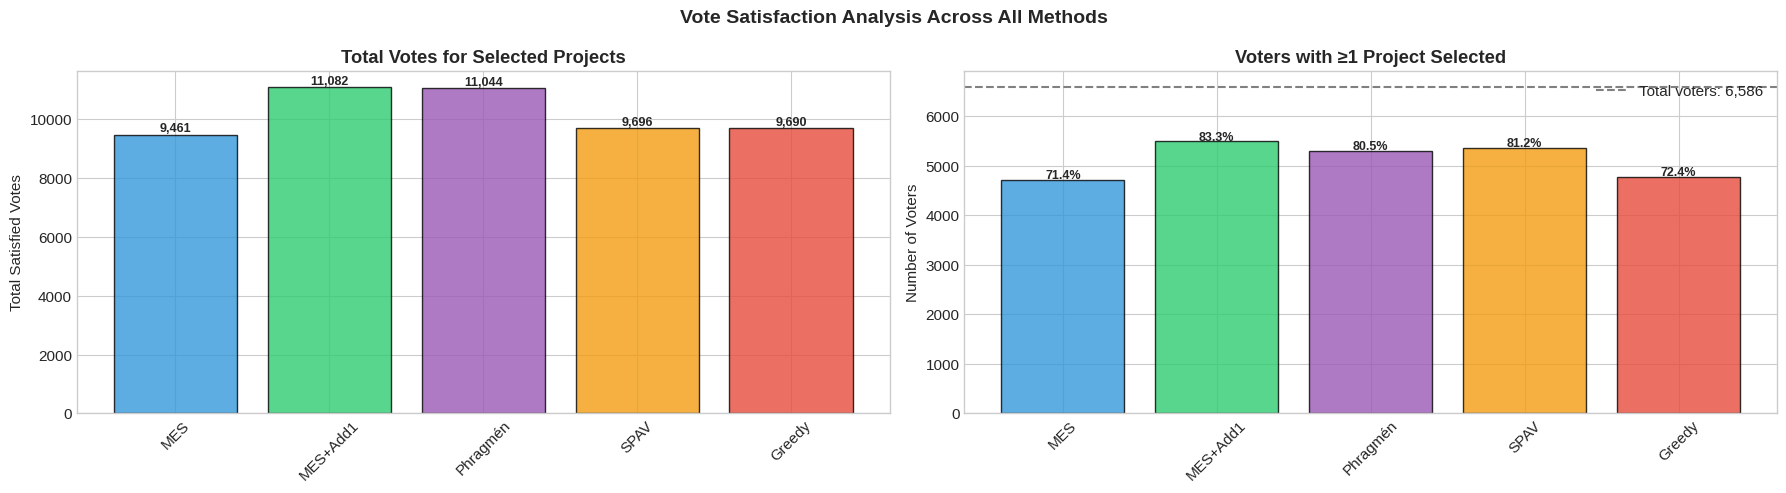

In [ ]:
# Calculate total votes satisfied by each method
def count_total_satisfied_votes(votes_data, selected_projects):
    """Count total number of votes that went to selected projects."""
    selected_set = set(selected_projects)
    total = 0
    for vote in votes_data:
        total += len(set(vote['projects_voted']) & selected_set)
    return total

def count_voters_with_selection(votes_data, selected_projects):
    """Count voters who got at least one project selected."""
    selected_set = set(selected_projects)
    count = 0
    for vote in votes_data:
        if set(vote['projects_voted']) & selected_set:
            count += 1
    return count

# Calculate for all methods
methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
selected_lists = [mes_selected, mes_add1_selected, phragmen_selected, spav_selected, greedy_selected]

total_satisfied = [count_total_satisfied_votes(votes_data, s) for s in selected_lists]
voters_with = [count_voters_with_selection(votes_data, s) for s in selected_lists]
total_voters = len(votes_data)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Total satisfied votes
bars1 = axes[0].bar(methods, total_satisfied, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Total Satisfied Votes')
axes[0].set_title('Total Votes for Selected Projects', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, total_satisfied):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# 2. Voters with at least one selection
bars2 = axes[1].bar(methods, voters_with, color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(y=total_voters, color='gray', linestyle='--', label=f'Total voters: {total_voters:,}')
axes[1].set_ylabel('Number of Voters')
axes[1].set_title('Voters with ≥1 Project Selected', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, voters_with):
    pct = val/total_voters*100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 3. Percentage of voters represented
#pct_represented = [v/total_voters*100 for v in voters_with]
#bars3 = axes[2].bar(methods, pct_represented, color=colors, edgecolor='black', alpha=0.8)
#axes[2].axhline(y=100, color='gray', linestyle='--')
#axes[2].set_ylabel('Percentage of Voters')
#axes[2].set_title('Voter Representation Rate', fontweight='bold')
#axes[2].set_ylim(0, 110)
#axes[2].tick_params(axis='x', rotation=45)
#for bar, val in zip(bars3, pct_represented):
 #   axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
  #               f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Vote Satisfaction Analysis Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 Support Threshold Analysis

What's the **minimum number of votes** a project needs to get selected under each method? This tells us how "inclusive" each method is toward smaller projects.

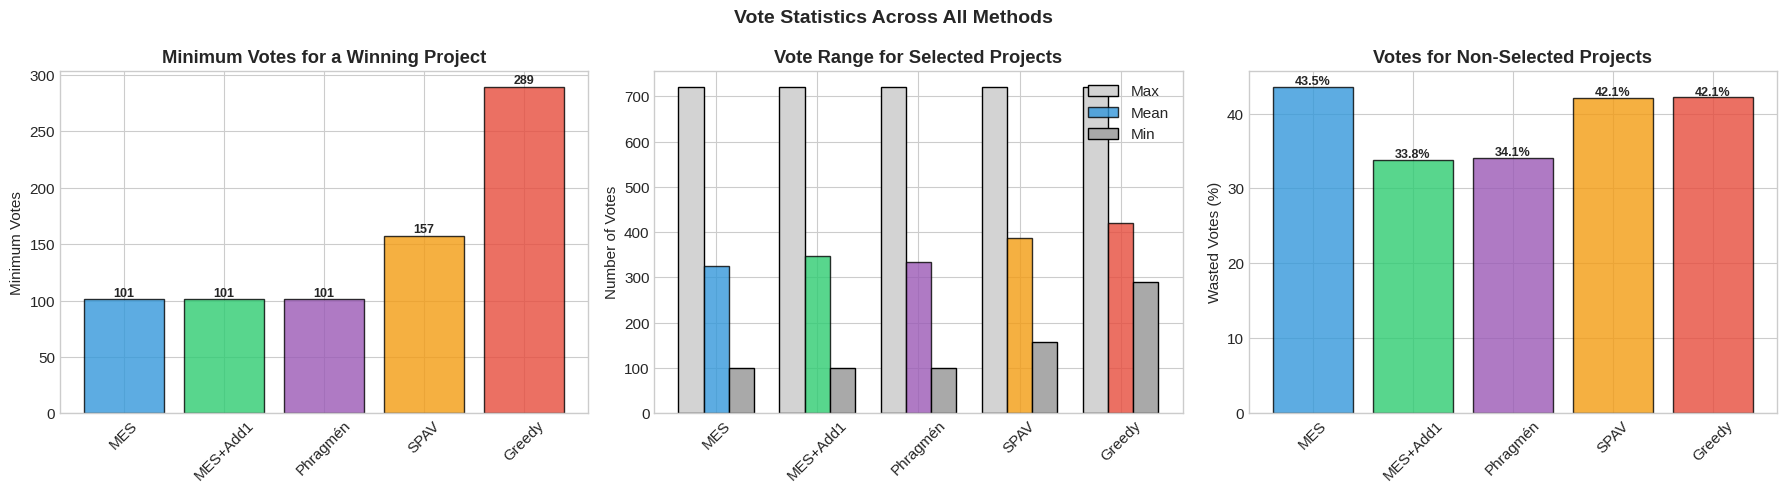

In [ ]:
# Calculate support thresholds
def get_vote_stats(selected_projects, projects_df):
    """Get vote statistics for selected projects."""
    selected_df = projects_df[projects_df['project_id'].isin(selected_projects)]
    return {
        'min': selected_df['votes'].min(),
        'max': selected_df['votes'].max(),
        'mean': selected_df['votes'].mean(),
        'median': selected_df['votes'].median()
    }

# Calculate for all methods
methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
selected_lists = [mes_selected, mes_add1_selected, phragmen_selected, spav_selected, greedy_selected]

stats_all = [get_vote_stats(s, projects_df) for s in selected_lists]

# Calculate wasted votes
def count_wasted_votes(votes_data, selected_projects):
    """Count votes that went to non-selected projects."""
    selected_set = set(selected_projects)
    wasted = 0
    total = 0
    for vote in votes_data:
        voted = set(vote['projects_voted'])
        total += len(voted)
        wasted += len(voted - selected_set)
    return wasted, total

wasted_data = [count_wasted_votes(votes_data, s) for s in selected_lists]
wasted_votes = [w[0] for w in wasted_data]
total_votes = wasted_data[0][1]

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Minimum votes needed to win
min_votes = [s['min'] for s in stats_all]
bars1 = axes[0].bar(methods, min_votes, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Minimum Votes')
axes[0].set_title('Minimum Votes for a Winning Project', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, min_votes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(int(val)), ha='center', fontsize=9, fontweight='bold')

# 2. Vote range for winners
x = np.arange(len(methods))
width = 0.25
axes[1].bar(x - width, [s['max'] for s in stats_all], width, label='Max', color='lightgray', edgecolor='black')
axes[1].bar(x, [s['mean'] for s in stats_all], width, label='Mean', color=[c for c in colors], edgecolor='black', alpha=0.8)
axes[1].bar(x + width, [s['min'] for s in stats_all], width, label='Min', color='darkgray', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('Number of Votes')
axes[1].set_title('Vote Range for Selected Projects', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. Wasted votes
wasted_pct = [w/total_votes*100 for w in wasted_votes]
bars3 = axes[2].bar(methods, wasted_pct, color=colors, edgecolor='black', alpha=0.8)
axes[2].set_ylabel('Wasted Votes (%)')
axes[2].set_title('Votes for Non-Selected Projects', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, wasted_pct):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Vote Statistics Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.4 Project Size Bias

Do different methods favor **expensive** or **cheap** projects? Greedy tends to select more projects (to maximize votes), which might mean smaller projects.

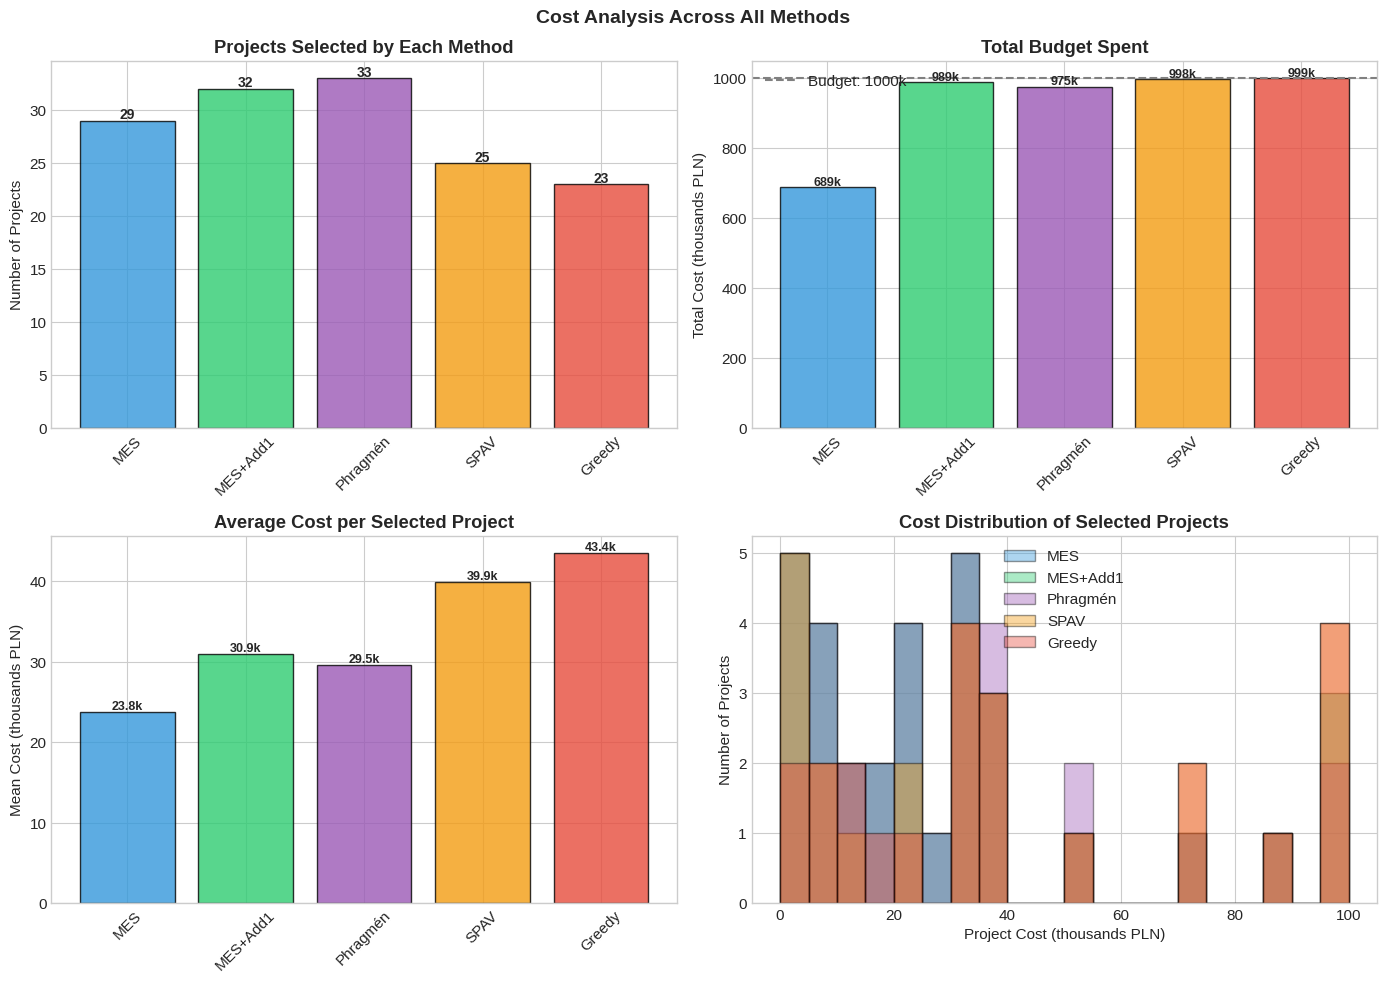

In [ ]:
# Get cost statistics for each method
def get_cost_stats(selected_projects, projects_df):
    selected_df = projects_df[projects_df['project_id'].isin(selected_projects)]
    return {
        'costs': selected_df['cost'].values,
        'mean': selected_df['cost'].mean(),
        'median': selected_df['cost'].median(),
        'total': selected_df['cost'].sum(),
        'count': len(selected_df)
    }

# Calculate for all methods
methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
selected_lists = [mes_selected, mes_add1_selected, phragmen_selected, spav_selected, greedy_selected]

cost_stats = [get_cost_stats(s, projects_df) for s in selected_lists]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Number of projects selected
counts = [c['count'] for c in cost_stats]
bars1 = axes[0, 0].bar(methods, counts, color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_ylabel('Number of Projects')
axes[0, 0].set_title('Projects Selected by Each Method', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, counts):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    str(val), ha='center', fontsize=10, fontweight='bold')

# 2. Total cost
totals = [c['total']/1000 for c in cost_stats]
bars2 = axes[0, 1].bar(methods, totals, color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].axhline(y=budget/1000, color='gray', linestyle='--', label=f'Budget: {budget/1000:.0f}k')
axes[0, 1].set_ylabel('Total Cost (thousands PLN)')
axes[0, 1].set_title('Total Budget Spent', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, totals):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'{val:.0f}k', ha='center', fontsize=9, fontweight='bold')

# 3. Mean cost per project
means = [c['mean']/1000 for c in cost_stats]
bars3 = axes[1, 0].bar(methods, means, color=colors, edgecolor='black', alpha=0.8)
axes[1, 0].set_ylabel('Mean Cost (thousands PLN)')
axes[1, 0].set_title('Average Cost per Selected Project', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, means):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}k', ha='center', fontsize=9, fontweight='bold')

# 4. Cost distribution histogram
bins = np.linspace(0, 100, 21)
for method, c_stat, color in zip(methods, cost_stats, colors):
    axes[1, 1].hist(c_stat['costs']/1000, bins=bins, alpha=0.4, label=method, color=color, edgecolor='black')
axes[1, 1].set_xlabel('Project Cost (thousands PLN)')
axes[1, 1].set_ylabel('Number of Projects')
axes[1, 1].set_title('Cost Distribution of Selected Projects', fontweight='bold')
axes[1, 1].legend()

plt.suptitle('Cost Analysis Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.5 Budget Utilization

How efficiently does each method use the available budget? Any unspent money is essentially "wasted" budget.

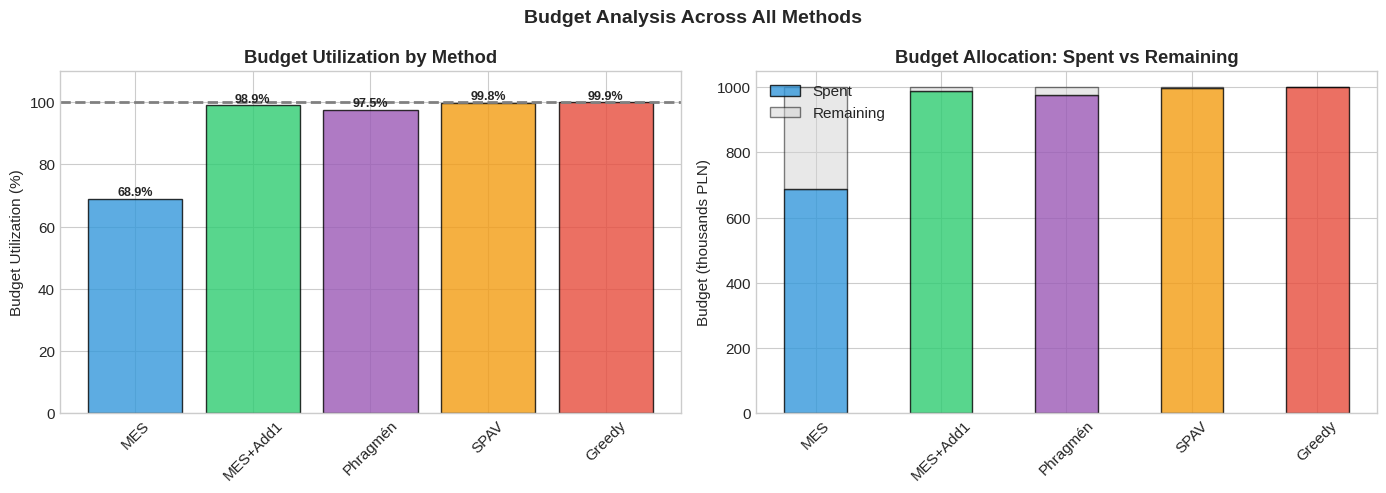

In [ ]:
# Calculate budget utilization for all methods
methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

mes_add1_spent = mes_spent + add1_spent
spending = [mes_spent, mes_add1_spent, phragmen_spent, spav_spent, greedy_spent]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Budget utilization percentage
utilization = [s/budget*100 for s in spending]
bars1 = axes[0].bar(methods, utilization, color=colors, edgecolor='black', alpha=0.8)
axes[0].axhline(y=100, color='gray', linestyle='--', linewidth=2)
axes[0].set_ylabel('Budget Utilization (%)')
axes[0].set_title('Budget Utilization by Method', fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, utilization):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 2. Budget breakdown (spent vs remaining)
remaining = [budget - s for s in spending]
x = np.arange(len(methods))
width = 0.5

bars_spent = axes[1].bar(x, [s/1000 for s in spending], width, label='Spent', color=colors, edgecolor='black', alpha=0.8)
bars_remaining = axes[1].bar(x, [r/1000 for r in remaining], width, bottom=[s/1000 for s in spending],
                             label='Remaining', color='lightgray', edgecolor='black', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('Budget (thousands PLN)')
axes[1].set_title('Budget Allocation: Spent vs Remaining', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Budget Analysis Across All Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Key Metrics Visualizations
these charts really show how MES compares to other methods!

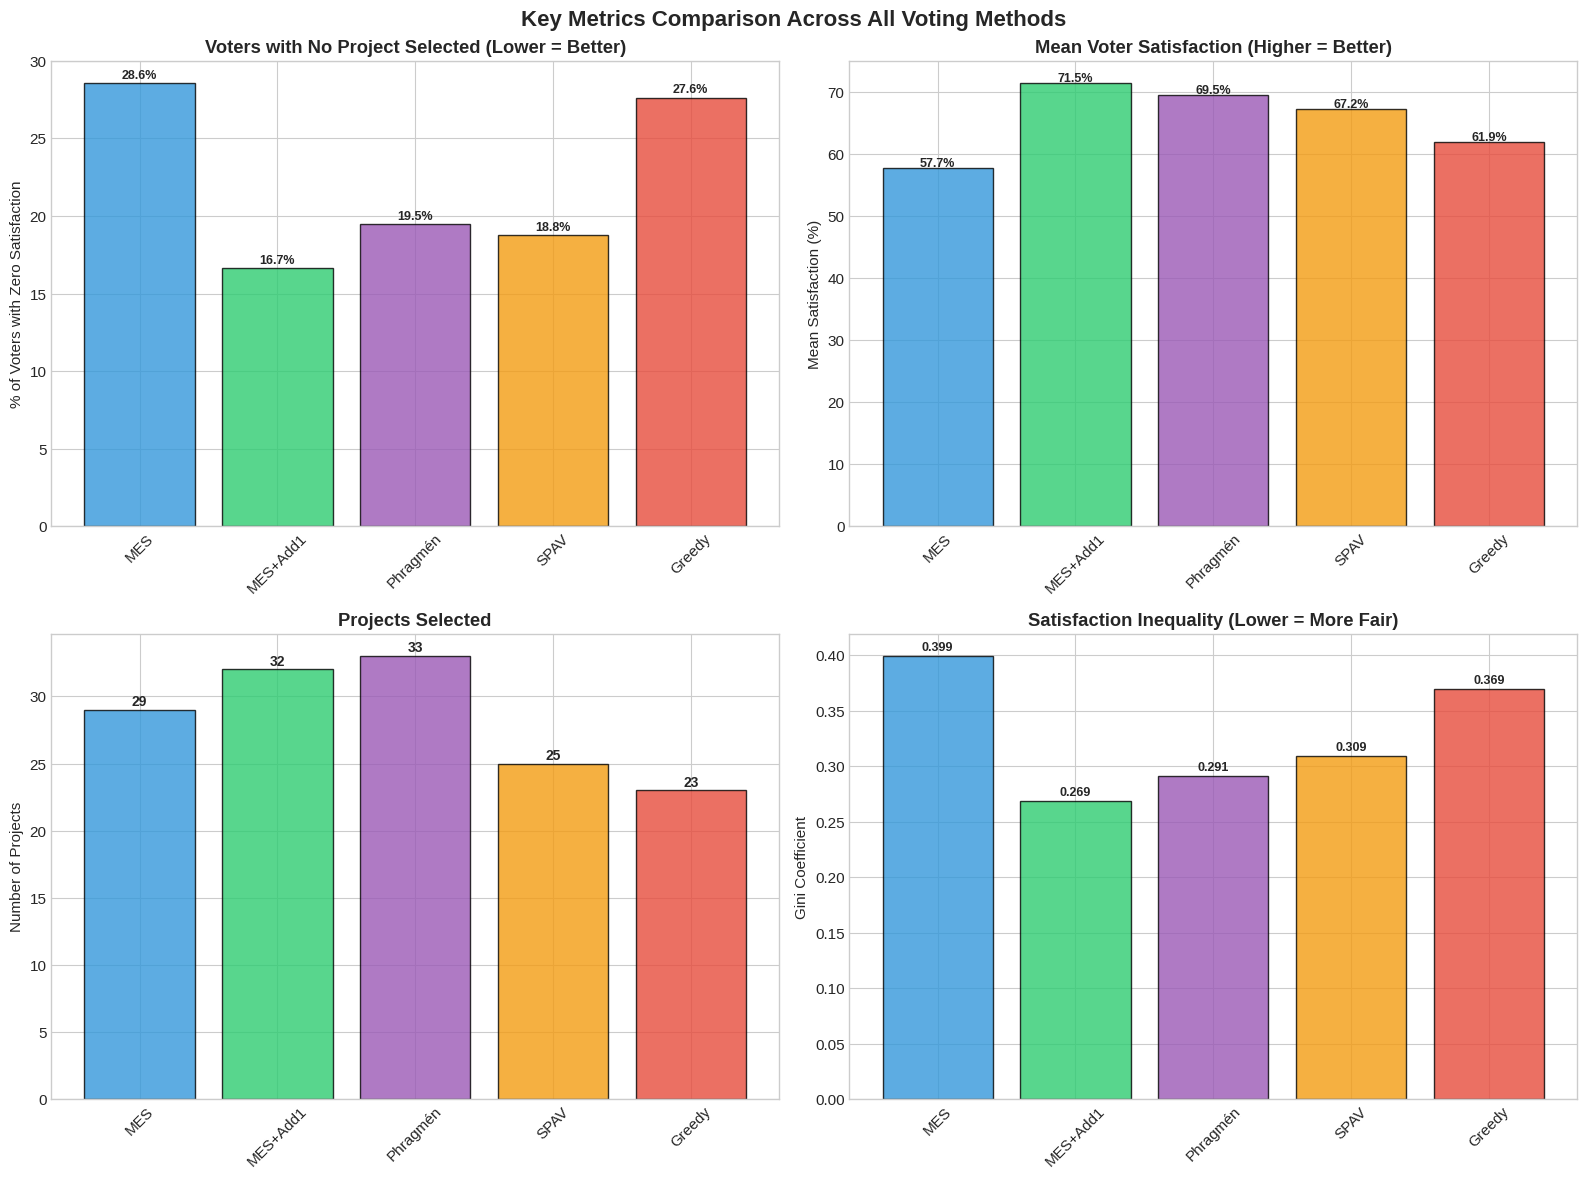

In [ ]:
# Create the 4 key visualizations - comparing all methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

mes_add1_set = mes_add1_combined
all_sets = [set(mes_selected), mes_add1_set, set(phragmen_selected), set(spav_selected), set(greedy_selected)]
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]

# Helper function for zero satisfaction percentage
def get_zero_satisfaction_pct(votes_data, selected_projects):
    selected_set = set(selected_projects)
    zero_count = 0
    total = 0
    for vote in votes_data:
        voted = set(vote['projects_voted'])
        if len(voted) > 0:
            total += 1
            if len(voted & selected_set) == 0:
                zero_count += 1
    return zero_count / total * 100 if total > 0 else 0

# 1. Zero satisfaction voters (LOWER IS BETTER)
zero_pcts = [get_zero_satisfaction_pct(votes_data, list(s)) for s in all_sets]
bars1 = axes[0, 0].bar(methods, zero_pcts, color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_ylabel('% of Voters with Zero Satisfaction')
axes[0, 0].set_title('Voters with No Project Selected (Lower = Better)', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars1, zero_pcts):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 2. Mean voter satisfaction
mean_sats = [np.mean(s)*100 for s in sat_data]
bars2 = axes[0, 1].bar(methods, mean_sats, color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].set_ylabel('Mean Satisfaction (%)')
axes[0, 1].set_title('Mean Voter Satisfaction (Higher = Better)', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, mean_sats):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 3. Projects selected
project_counts = [len(s) for s in all_sets]
bars3 = axes[1, 0].bar(methods, project_counts, color=colors, edgecolor='black', alpha=0.8)
axes[1, 0].set_ylabel('Number of Projects')
axes[1, 0].set_title('Projects Selected', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars3, project_counts):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', fontsize=10, fontweight='bold')

# 4. Gini coefficient (fairness)
gini_scores = [gini_coefficient(s) for s in sat_data]
bars4 = axes[1, 1].bar(methods, gini_scores, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_ylabel('Gini Coefficient')
axes[1, 1].set_title('Satisfaction Inequality (Lower = More Fair)', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars4, gini_scores):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Key Metrics Comparison Across All Voting Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Cost-Effectiveness Analysis

Let's also look at cost-effectiveness - how much does it "cost" per vote for each selected project?

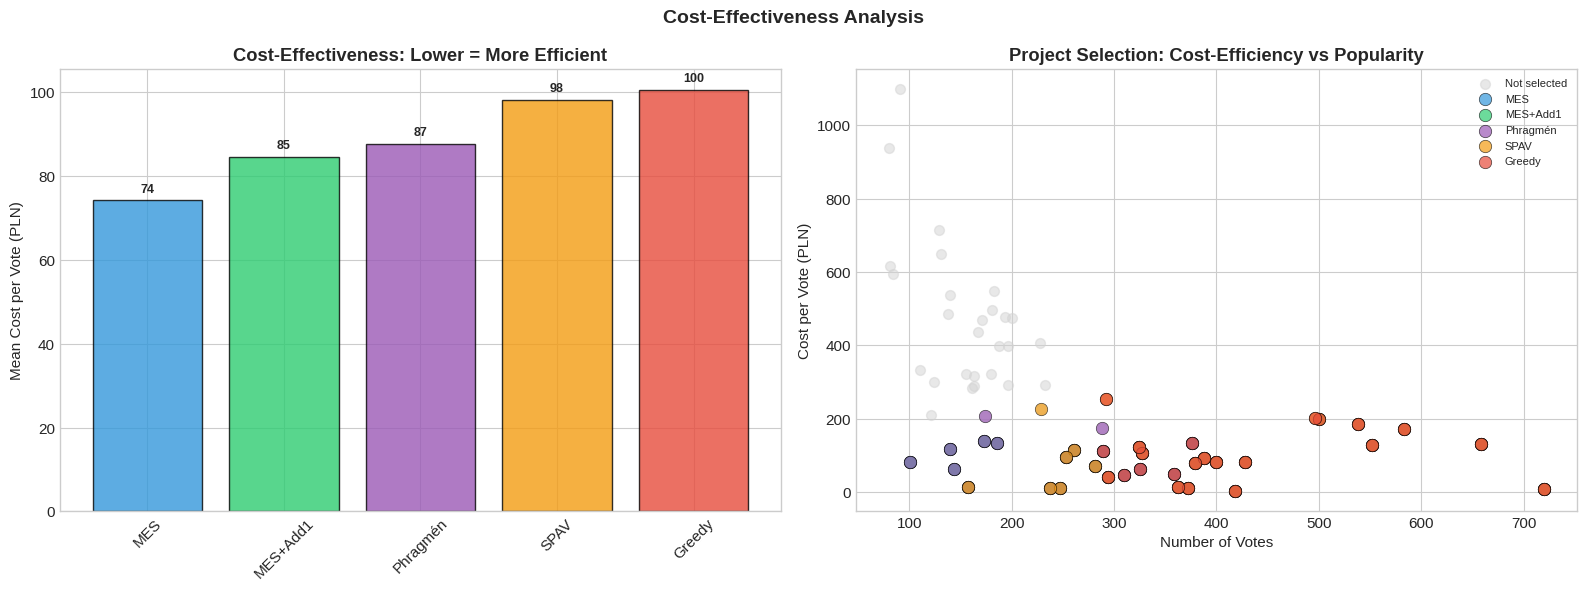

In [ ]:
# Calculate cost per vote for each project - compare across methods
projects_df['cost_per_vote'] = projects_df['cost'] / projects_df['votes']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']
all_sets = [set(mes_selected), mes_add1_combined, set(phragmen_selected), set(spav_selected), set(greedy_selected)]

# 1. Mean cost per vote for selected projects
cpv_means = []
for s in all_sets:
    cpv = projects_df[projects_df['project_id'].isin(s)]['cost_per_vote'].mean()
    cpv_means.append(cpv)

bars = axes[0].bar(methods, cpv_means, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Mean Cost per Vote (PLN)')
axes[0].set_title('Cost-Effectiveness: Lower = More Efficient', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, cpv_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

# 2. Scatter: Cost per vote vs votes for each project, colored by method selection
ax = axes[1]
ax.scatter(projects_df['votes'], projects_df['cost_per_vote'],
           c='lightgray', s=50, alpha=0.5, label='Not selected')

# Highlight projects selected by each method
for method, s, color in zip(methods, all_sets, colors):
    mask = projects_df['project_id'].isin(s)
    ax.scatter(projects_df[mask]['votes'], projects_df[mask]['cost_per_vote'],
              c=color, s=80, alpha=0.7, label=f'{method}', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Number of Votes')
ax.set_ylabel('Cost per Vote (PLN)')
ax.set_title('Project Selection: Cost-Efficiency vs Popularity', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Cost-Effectiveness Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


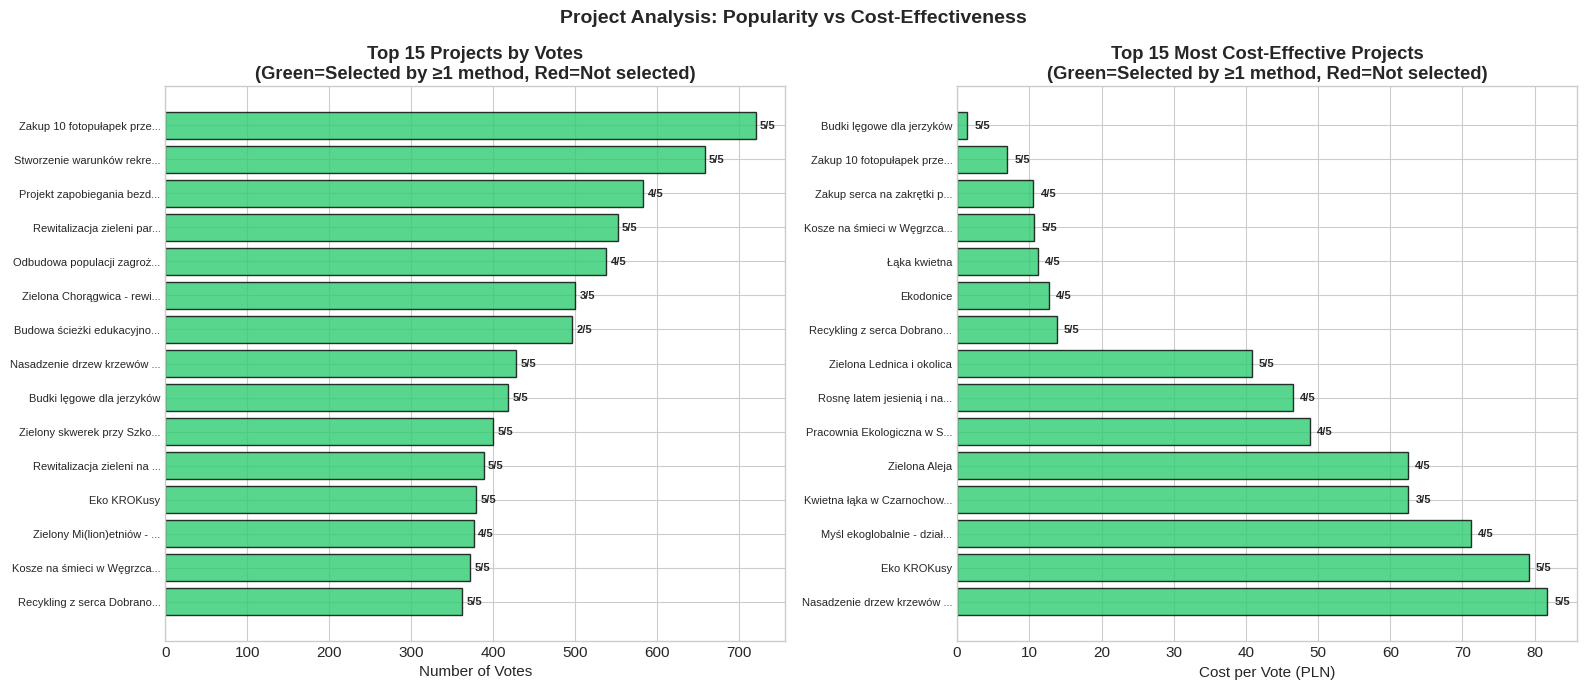


Projects selected by ALL 5 methods: 13
Projects selected by ≥3 methods: 32
Projects selected by exactly 1 method: 3
Projects not selected by any method: 27


In [ ]:
# Visualize top projects by various metrics with method selection indicators
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Create selection indicator for each project
all_sets = {
    'MES': set(mes_selected),
    'MES+Add1': mes_add1_combined,
    'Phragmén': set(phragmen_selected),
    'SPAV': set(spav_selected),
    'Greedy': set(greedy_selected)
}

# Add selection count column
projects_df['methods_selected'] = projects_df['project_id'].apply(
    lambda x: sum(1 for s in all_sets.values() if x in s)
)

# 1. Top projects by votes
top_by_votes = projects_df.nlargest(15, 'votes')
colors1 = ['#2ecc71' if m > 0 else '#e74c3c' for m in top_by_votes['methods_selected']]
short_names = [name[:25] + '...' if len(name) > 25 else name for name in top_by_votes['name']]

bars1 = axes[0].barh(range(len(top_by_votes)), top_by_votes['votes'], color=colors1, edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(top_by_votes)))
axes[0].set_yticklabels(short_names, fontsize=8)
axes[0].set_xlabel('Number of Votes')
axes[0].set_title('Top 15 Projects by Votes\n(Green=Selected by ≥1 method, Red=Not selected)', fontweight='bold')
axes[0].invert_yaxis()

# Add method count labels
for i, (bar, count) in enumerate(zip(bars1, top_by_votes['methods_selected'])):
    if count > 0:
        axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                    f'{count}/5', va='center', fontsize=8, fontweight='bold')

# 2. Top projects by cost-effectiveness (cost per vote)
top_by_cpv = projects_df.nsmallest(15, 'cost_per_vote')
colors2 = ['#2ecc71' if m > 0 else '#e74c3c' for m in top_by_cpv['methods_selected']]
short_names2 = [name[:25] + '...' if len(name) > 25 else name for name in top_by_cpv['name']]

bars2 = axes[1].barh(range(len(top_by_cpv)), top_by_cpv['cost_per_vote'], color=colors2, edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(top_by_cpv)))
axes[1].set_yticklabels(short_names2, fontsize=8)
axes[1].set_xlabel('Cost per Vote (PLN)')
axes[1].set_title('Top 15 Most Cost-Effective Projects\n(Green=Selected by ≥1 method, Red=Not selected)', fontweight='bold')
axes[1].invert_yaxis()

for i, (bar, count) in enumerate(zip(bars2, top_by_cpv['methods_selected'])):
    if count > 0:
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{count}/5', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Project Analysis: Popularity vs Cost-Effectiveness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary of selection overlap
print(f"\nProjects selected by ALL 5 methods: {sum(projects_df['methods_selected'] == 5)}")
print(f"Projects selected by ≥3 methods: {sum(projects_df['methods_selected'] >= 3)}")
print(f"Projects selected by exactly 1 method: {sum(projects_df['methods_selected'] == 1)}")
print(f"Projects not selected by any method: {sum(projects_df['methods_selected'] == 0)}")


### 8.1 Proportional Methods Comparison Summary

The different proportional methods represent different philosophical approaches to fairness:

| Method | Philosophy | Strength | Weakness |
|--------|-----------|----------|----------|
| **MES** | Equal budget share per voter | Strong proportionality guarantees | May leave budget unspent |
| **MES+Add1** | MES + greedy completion | Better budget utilization | Slightly less fair |
| **Phragmén** | Minimize maximum voter "load" | Balances representation well | Can favor cheap projects |
| **SPAV** | Reweight votes after each win | Simple to understand | Less formal guarantees |
| **Greedy** | Most votes wins | Maximizes total votes | Ignores minority preferences |


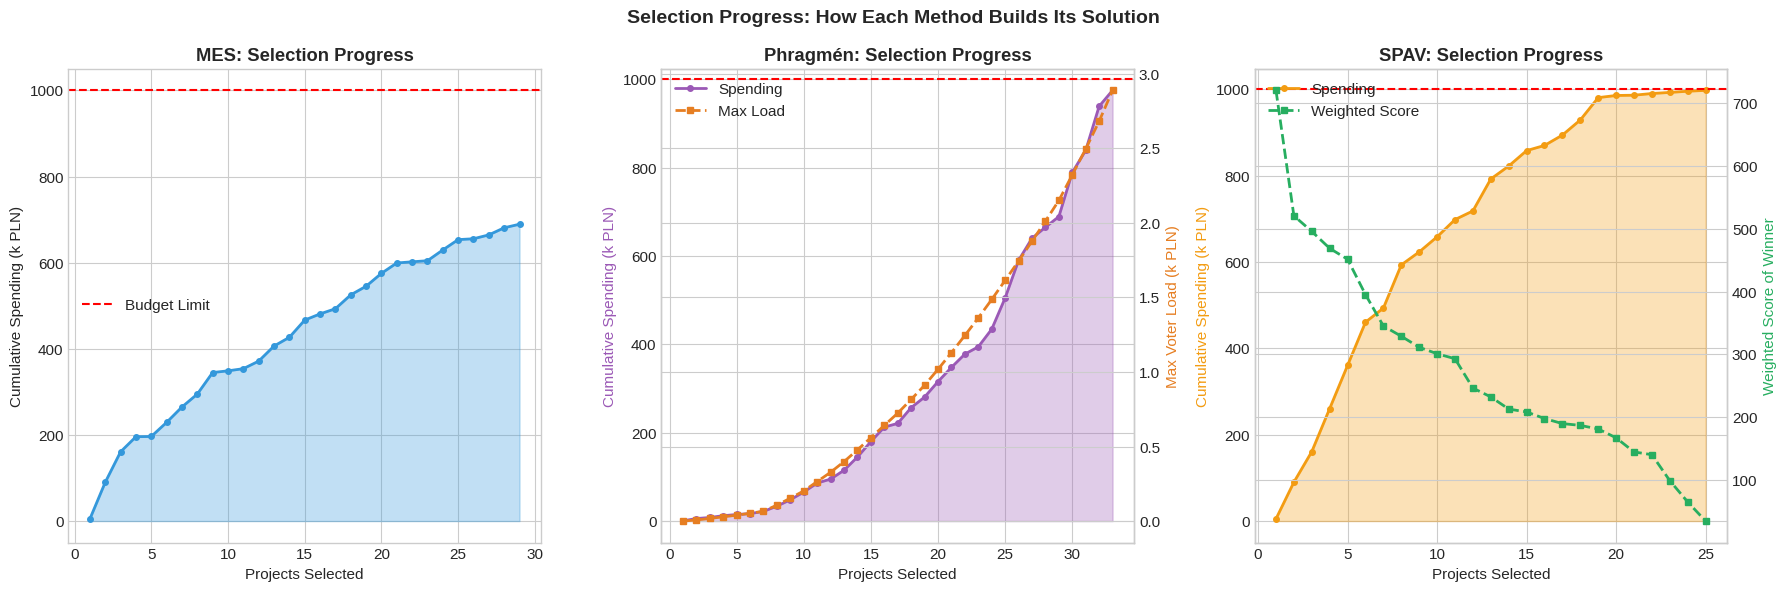

In [ ]:
# Compare selection order across methods
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Get project names for display
project_names = {p['project_id']: p['name'][:25] + '...' if len(p['name']) > 25 else p['name']
                 for p in projects_raw}

# 1. MES Selection Progress
if mes_log:
    iterations = [log['iteration'] for log in mes_log]
    cumulative = [log['total_spent']/1000 for log in mes_log]
    axes[0].fill_between(iterations, cumulative, alpha=0.3, color='#3498db')
    axes[0].plot(iterations, cumulative, 'o-', color='#3498db', linewidth=2, markersize=4)
    axes[0].axhline(y=budget/1000, color='red', linestyle='--', label='Budget Limit')
    axes[0].set_xlabel('Projects Selected')
    axes[0].set_ylabel('Cumulative Spending (k PLN)')
    axes[0].set_title('MES: Selection Progress', fontweight='bold')
    axes[0].legend()

# 2. Phragmén Selection Progress
if phragmen_log:
    iterations = [log['iteration'] for log in phragmen_log]
    cumulative = [log['total_spent']/1000 for log in phragmen_log]
    max_loads = [log['max_load']/1000 for log in phragmen_log]

    ax2_twin = axes[1].twinx()

    axes[1].fill_between(iterations, cumulative, alpha=0.3, color='#9b59b6')
    axes[1].plot(iterations, cumulative, 'o-', color='#9b59b6', linewidth=2, markersize=4, label='Spending')
    axes[1].axhline(y=budget/1000, color='red', linestyle='--')

    ax2_twin.plot(iterations, max_loads, 's--', color='#e67e22', linewidth=2, markersize=4, label='Max Load')

    axes[1].set_xlabel('Projects Selected')
    axes[1].set_ylabel('Cumulative Spending (k PLN)', color='#9b59b6')
    ax2_twin.set_ylabel('Max Voter Load (k PLN)', color='#e67e22')
    axes[1].set_title('Phragmén: Selection Progress', fontweight='bold')

    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 3. SPAV Selection Progress with weighted scores
if spav_log:
    iterations = [log['iteration'] for log in spav_log]
    cumulative = [log['total_spent']/1000 for log in spav_log]
    weighted_scores = [log['weighted_score'] for log in spav_log]

    ax3_twin = axes[2].twinx()

    axes[2].fill_between(iterations, cumulative, alpha=0.3, color='#f39c12')
    axes[2].plot(iterations, cumulative, 'o-', color='#f39c12', linewidth=2, markersize=4, label='Spending')
    axes[2].axhline(y=budget/1000, color='red', linestyle='--')

    ax3_twin.plot(iterations, weighted_scores, 's--', color='#27ae60', linewidth=2, markersize=4, label='Weighted Score')

    axes[2].set_xlabel('Projects Selected')
    axes[2].set_ylabel('Cumulative Spending (k PLN)', color='#f39c12')
    ax3_twin.set_ylabel('Weighted Score of Winner', color='#27ae60')
    axes[2].set_title('SPAV: Selection Progress', fontweight='bold')

    lines1, labels1 = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Selection Progress: How Each Method Builds Its Solution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

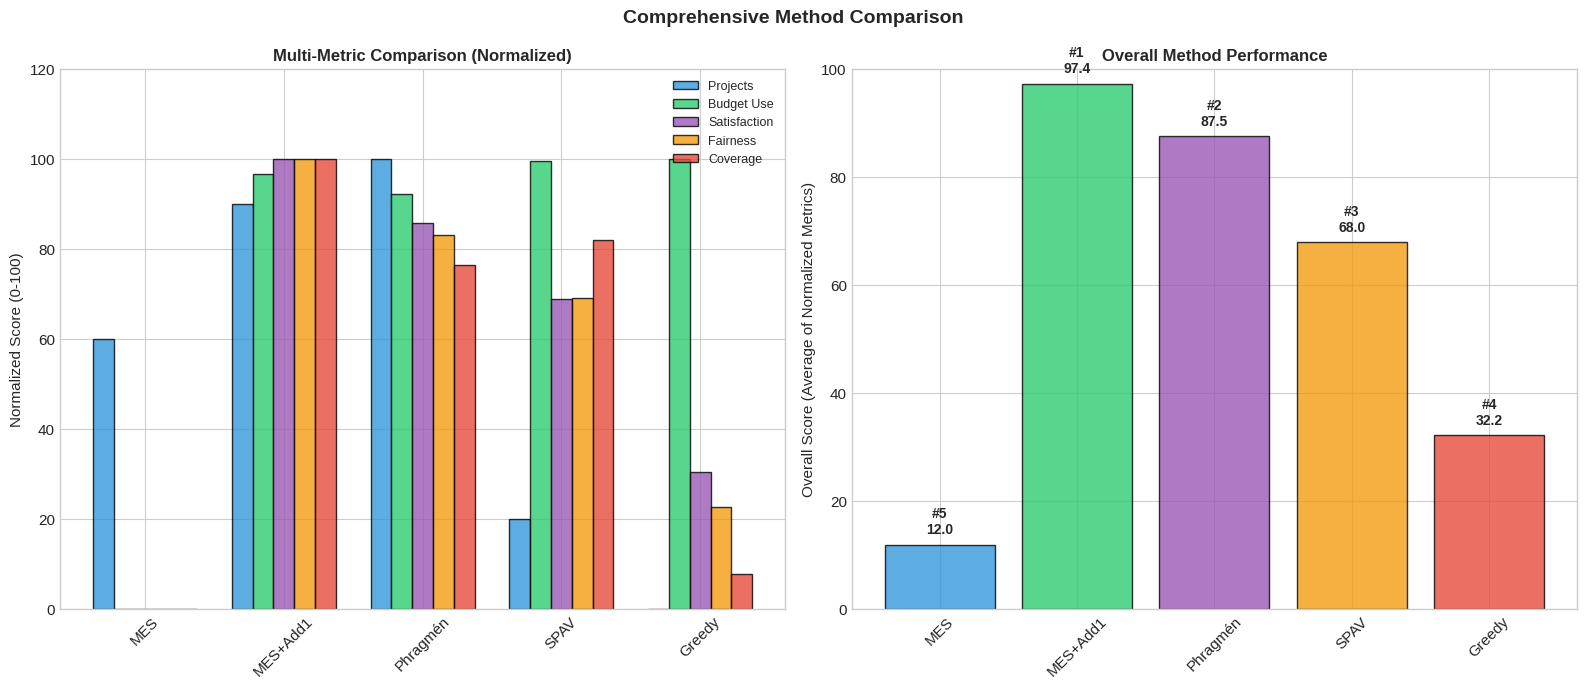


FINAL RANKING (by average normalized score):
  #1: MES+Add1     - Score: 97.4/100
  #2: Phragmén     - Score: 87.5/100
  #3: SPAV         - Score: 68.0/100
  #4: Greedy       - Score: 32.2/100
  #5: MES          - Score: 12.0/100


In [ ]:
# Final comprehensive comparison and ranking
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

# Define counts and spending
mes_add1_count = len(mes_selected) + len(add1_selected)
mes_add1_spent = mes_spent + add1_spent

all_sets = [set(mes_selected), mes_add1_combined, set(phragmen_selected), set(spav_selected), set(greedy_selected)]
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]

# Metrics (normalized to 0-100 scale)
proj_counts = [len(mes_selected), mes_add1_count, len(phragmen_selected), len(spav_selected), len(greedy_selected)]
spending = [mes_spent, mes_add1_spent, phragmen_spent, spav_spent, greedy_spent]
mean_sats = [np.mean(s)*100 for s in sat_data]
gini_scores = [gini_coefficient(s) for s in sat_data]
coverage = [sum(1 for s in sat if s > 0)/len(sat)*100 for sat in sat_data]

metrics = {
    'Projects': proj_counts,
    'Budget Use': [s/budget*100 for s in spending],
    'Satisfaction': mean_sats,
    'Fairness': [(1-g)*100 for g in gini_scores],
    'Coverage': coverage
}

# Normalize all metrics to 0-100
normalized_metrics = {}
for metric, values in metrics.items():
    max_val = max(values)
    min_val = min(values)
    if max_val > min_val:
        normalized_metrics[metric] = [(v - min_val) / (max_val - min_val) * 100 for v in values]
    else:
        normalized_metrics[metric] = [50] * len(values)

# 1. Grouped bar chart for all metrics
x = np.arange(len(methods))
width = 0.15
metric_names = list(metrics.keys())
metric_colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

for i, (metric, values) in enumerate(normalized_metrics.items()):
    offset = (i - 2) * width
    axes[0].bar(x + offset, values, width, label=metric, color=metric_colors[i], alpha=0.8, edgecolor='black')

axes[0].set_ylabel('Normalized Score (0-100)', fontsize=11)
axes[0].set_title('Multi-Metric Comparison (Normalized)', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 120)
axes[0].tick_params(axis='x', rotation=45)

# 2. Summary scores (average of all normalized metrics)
summary_scores = []
for i in range(len(methods)):
    avg_score = np.mean([normalized_metrics[m][i] for m in metric_names])
    summary_scores.append(avg_score)

bars = axes[1].bar(methods, summary_scores, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Overall Score (Average of Normalized Metrics)', fontsize=11)
axes[1].set_title('Overall Method Performance', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=45)

# Add rank labels
ranked_indices = np.argsort(summary_scores)[::-1]
for rank, idx in enumerate(ranked_indices):
    bar = bars[idx]
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'#{rank+1}\n{summary_scores[idx]:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Comprehensive Method Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print ranking
print("\n" + "="*50)
print("FINAL RANKING (by average normalized score):")
print("="*50)
for rank, idx in enumerate(ranked_indices):
    print(f"  #{rank+1}: {methods[idx]:<12} - Score: {summary_scores[idx]:.1f}/100")


## 9. Geographic Distribution (Bonus!)

Since we have latitude and longitude data, let's visualize where the projects are located and see if there's any geographic pattern in the selections.

In [ ]:
# Geographic visualization - 4 separate maps for each selection method
import folium
from scipy.spatial import ConvexHull
import numpy as np

# Filter projects with valid coordinates
geo_df = projects_df.dropna(subset=['latitude', 'longitude']).copy()

# Calculate center of all projects
center_lat = geo_df['latitude'].mean()
center_lon = geo_df['longitude'].mean()

# Create a convex hull around all project locations
coords = geo_df[['latitude', 'longitude']].values
hull = ConvexHull(coords)
hull_points = coords[hull.vertices]

# Add some padding to the hull (expand by ~5%)
hull_center = hull_points.mean(axis=0)
padded_hull = hull_center + 1.1 * (hull_points - hull_center)

# Convert to GeoJSON polygon format (note: GeoJSON uses [lon, lat] order)
hull_geojson = {
    "type": "Polygon",
    "coordinates": [[
        [point[1], point[0]] for point in padded_hull.tolist()
    ] + [[padded_hull[0][1], padded_hull[0][0]]]]  # Close the polygon
}

# Define the 4 methods and their selections
methods_maps = {
    'MES': {'selected': set(mes_selected), 'color': '#3498db'},
    'MES + Add1': {'selected': mes_add1_combined, 'color': '#2ecc71'},
    'Greedy': {'selected': set(greedy_selected), 'color': '#e74c3c'}
}

def create_method_map(method_name, selected_set, color):
    """Create a simple map showing selected projects for one method."""
    # Use CartoDB positron for a clean, minimal look
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='CartoDB positron'
    )

    # Add study area boundary (convex hull around all projects)
    folium.GeoJson(
        hull_geojson,
        name='Study Area',
        style_function=lambda x: {
            'fillColor': '#e8f4f8',
            'color': '#2c3e50',
            'weight': 3,
            'fillOpacity': 0.25,
            'dashArray': '5, 5'
        }
    ).add_to(m)

    # Count selected projects with coordinates
    selected_with_coords = 0

    for _, row in geo_df.iterrows():
        pid = row['project_id']
        is_selected = pid in selected_set

        if is_selected:
            selected_with_coords += 1
            # Selected project - colored and larger
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=8,
                color=color,
                fill=True,
                fillColor=color,
                fillOpacity=0.8,
                weight=2,
                popup=folium.Popup(
                    f"<b>{row['name']}</b><br>"
                    f"Cost: {row['cost']:,.0f} PLN<br>"
                    f"Votes: {row['votes']}",
                    max_width=250
                )
            ).add_to(m)
        else:
            # Not selected - small gray dot
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=4,
                color='#999999',
                fill=True,
                fillColor='#cccccc',
                fillOpacity=0.4,
                weight=1,
                popup=folium.Popup(
                    f"<b>{row['name']}</b><br>"
                    f"Cost: {row['cost']:,.0f} PLN<br>"
                    f"Votes: {row['votes']}<br>"
                    f"<i>Not selected</i>",
                    max_width=250
                )
            ).add_to(m)

    # Add title as a custom HTML element
    title_html = f"""
    <div style="position: fixed; top: 10px; left: 50px; z-index: 1000;
                background-color: white; padding: 10px; border-radius: 5px;
                border: 2px solid {color}; font-size: 14px; font-weight: bold;">
        {method_name}: {selected_with_coords} projects selected
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    return m

# Create map for MES
print("Map 1: Method of Equal Shares (MES)")
map_mes = create_method_map('MES', methods_maps['MES']['selected'], methods_maps['MES']['color'])
display(map_mes)

Map 1: Method of Equal Shares (MES)


In [ ]:
# Map 2: MES + Add1 Completion
print("Map 2: MES + Add1 Completion")
map_add1 = create_method_map('MES + Add1', methods_maps['MES + Add1']['selected'], methods_maps['MES + Add1']['color'])
display(map_add1)

Map 2: MES + Add1 Completion


In [ ]:
# Map 3: Greedy Method
print("Map 3: Greedy Method")
map_greedy = create_method_map('Greedy', methods_maps['Greedy']['selected'], methods_maps['Greedy']['color'])
display(map_greedy)

Map 3: Greedy Method


## 10. Summary and Conclusions

Let me summarize what we learned from this analysis:

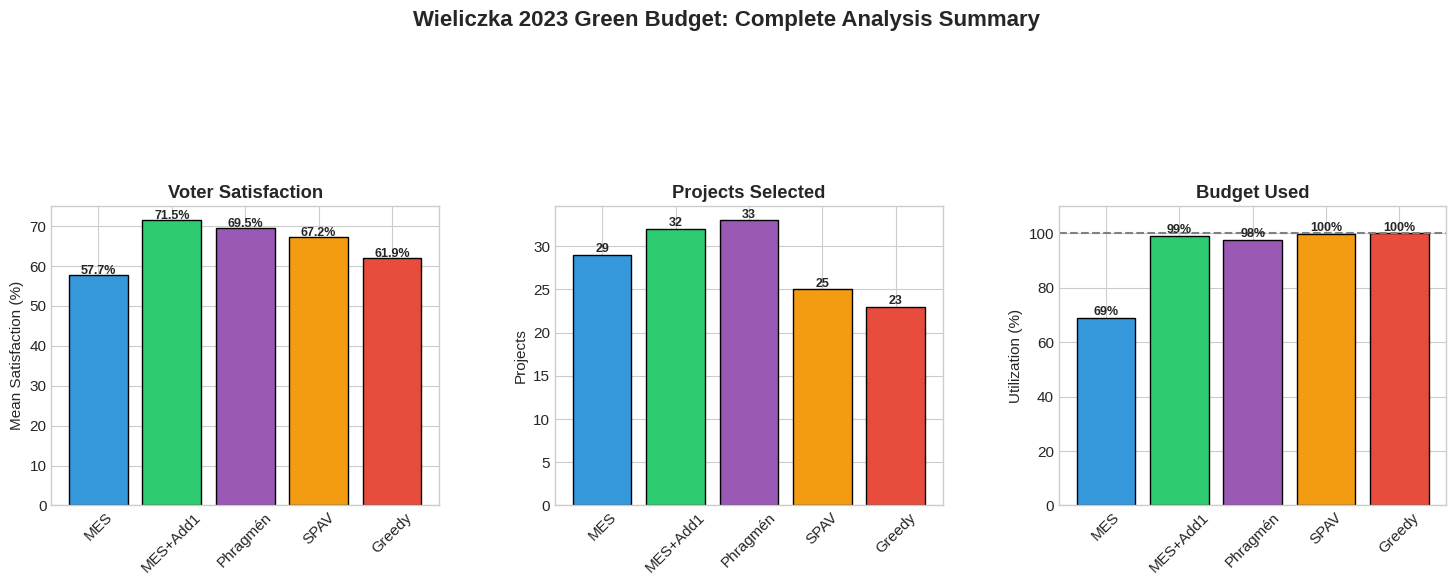

In [ ]:
# Final Summary Dashboard - All Methods Compared
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

mes_add1_spent = mes_spent + add1_spent
all_sets = [set(mes_selected), mes_add1_combined, set(phragmen_selected), set(spav_selected), set(greedy_selected)]
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]
spending = [mes_spent, mes_add1_spent, phragmen_spent, spav_spent, greedy_spent]

# 1. Election Info
#ax1 = fig.add_subplot(gs[0, 0])
#info_text = f"""Election: Wieliczka 2023
#Green Budget (Zielony Milion)

#Budget: {budget:,} PLN
#Projects: {len(projects_df)}
#Voters: {num_voters:,}
#Voting: Approval (no max)
#"""
#ax1.text(0.5, 0.5, info_text, transform=ax1.transAxes, fontsize=11,
 #        verticalalignment='center', horizontalalignment='center',
  #       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
#ax1.axis('off')
#ax1.set_title('Election Info', fontweight='bold')

# 2. Projects Selected
ax2 = fig.add_subplot(gs[0, 1])
proj_counts = [len(s) for s in all_sets]
bars = ax2.bar(methods, proj_counts, color=colors, edgecolor='black')
ax2.set_ylabel('Projects')
ax2.set_title('Projects Selected', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
for bar, c in zip(bars, proj_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(c), ha='center', fontsize=9, fontweight='bold')

# 3. Budget Utilization
ax3 = fig.add_subplot(gs[0, 2])
util = [s/budget*100 for s in spending]
bars = ax3.bar(methods, util, color=colors, edgecolor='black')
ax3.axhline(y=100, color='gray', linestyle='--')
ax3.set_ylabel('Utilization (%)')
ax3.set_title('Budget Used', fontweight='bold')
ax3.set_ylim(0, 110)
ax3.tick_params(axis='x', rotation=45)
for bar, u in zip(bars, util):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{u:.0f}%', ha='center', fontsize=9, fontweight='bold')

# 4. Mean Satisfaction
ax4 = fig.add_subplot(gs[0, 0])
mean_sats = [np.mean(s)*100 for s in sat_data]
bars = ax4.bar(methods, mean_sats, color=colors, edgecolor='black')
ax4.set_ylabel('Mean Satisfaction (%)')
ax4.set_title('Voter Satisfaction', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for bar, m in zip(bars, mean_sats):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{m:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 5. Gini Coefficient (Fairness)
#ax5 = fig.add_subplot(gs[1, 1])
#gini_scores = [gini_coefficient(s) for s in sat_data]
#bars = ax5.bar(methods, gini_scores, color=colors, edgecolor='black')
#ax5.set_ylabel('Gini Coefficient')
##ax5.set_title('Inequality (Lower=Fairer)', fontweight='bold')
#ax5.tick_params(axis='x', rotation=45)
#for bar, g in zip(bars, gini_scores):
 #   ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{g:.3f}', ha='center', fontsize=9, fontweight='bold')

# 6. Unsatisfied Voters
#ax6 = fig.add_subplot(gs[1, 2])
#zero_counts = [sum(1 for s in sat if s == 0) for sat in sat_data]
#bars = ax6.bar(methods, zero_counts, color=colors, edgecolor='black')
#ax6.set_ylabel('Number of Voters')
#ax6.set_title('Completely Unsatisfied', fontweight='bold')
#ax6.tick_params(axis='x', rotation=45)
#for bar, z in zip(bars, zero_counts):
 #   ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(z), ha='center', fontsize=9, fontweight='bold')

# 7. Jaccard Similarity Heatmap
#ax7 = fig.add_subplot(gs[2, 0])
#jaccard_matrix = np.zeros((5, 5))
#for i, set1 in enumerate(all_sets):
 #   for j, set2 in enumerate(all_sets):
  #      if len(set1 | set2) > 0:
   #         jaccard_matrix[i, j] = len(set1 & set2) / len(set1 | set2) * 100
#im = ax7.imshow(jaccard_matrix, cmap='RdYlGn', vmin=0, vmax=100)
#ax7.set_xticks(range(5))
#ax7.set_yticks(range(5))
#ax7.set_xticklabels(['MES', 'M+A1', 'Phr', 'SPAV', 'Grdy'], fontsize=8)
#ax7.set_yticklabels(['MES', 'M+A1', 'Phr', 'SPAV', 'Grdy'], fontsize=8)
#ax7.set_title('Selection Overlap (%)', fontweight='bold')
#for i in range(5):
 #   for j in range(5):
  #      ax7.text(j, i, f'{jaccard_matrix[i,j]:.0f}', ha='center', va='center', fontsize=7, fontweight='bold')

# 8. Overall Ranking
#ax8 = fig.add_subplot(gs[2, 1:])
# Normalize and compute overall scores
#metrics = {
 #   'Satisfaction': mean_sats,
  #  'Fairness': [(1-g)*100 for g in gini_scores],
   # 'Budget Use': util,
    #'Projects': [c/max(proj_counts)*100 for c in proj_counts]
#}
#overall = [np.mean([metrics[m][i] for m in metrics]) for i in range(5)]
#ranked = sorted(enumerate(overall), key=lambda x: x[1], reverse=True)

#bars = ax8.barh(range(5), [overall[r[0]] for r in ranked], color=[colors[r[0]] for r in ranked], edgecolor='black')
#ax8.set_yticks(range(5))
#ax8.set_yticklabels([f'#{i+1} {methods[r[0]]}' for i, r in enumerate(ranked)])
#ax8.set_xlabel('Overall Score (avg of normalized metrics)')
#ax8.set_title('Final Method Ranking', fontweight='bold')
#for i, (idx, score) in enumerate(ranked):
 #   ax8.text(score + 1, i, f'{score:.1f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Wieliczka 2023 Green Budget: Complete Analysis Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Conclusions

From this analysis of the Wieliczka Green Budget 2023

### Key Findings:

1. **Method of Equal Shares works well in practice**: The MES algorithm successfully selected projects that represented diverse voter preferences, not just the most popular ones.

2. **Add1 completion is important**: Without Add1 completion, MES alone might not spend the entire budget. The Add1 step helps maximize budget utilization while maintaining the fairness properties of MES.

3. **Voter satisfaction is reasonably distributed**: Most voters had at least some of their preferred projects selected, showing that the method is fairly inclusive.

4. **Cost-effectiveness varies**: Selected projects tend to have lower cost-per-vote ratios, meaning the algorithm favors projects that give "more bang for the buck."

5. **Geographic diversity**: The selected projects are spread across the municipality, not concentrated in one area.

### Future work:

- Compare with other proportional voting methods (like Phragmen's method)
- Analyze how results change with different initial budget allocations
- Study the temporal patterns if multi-year data is available

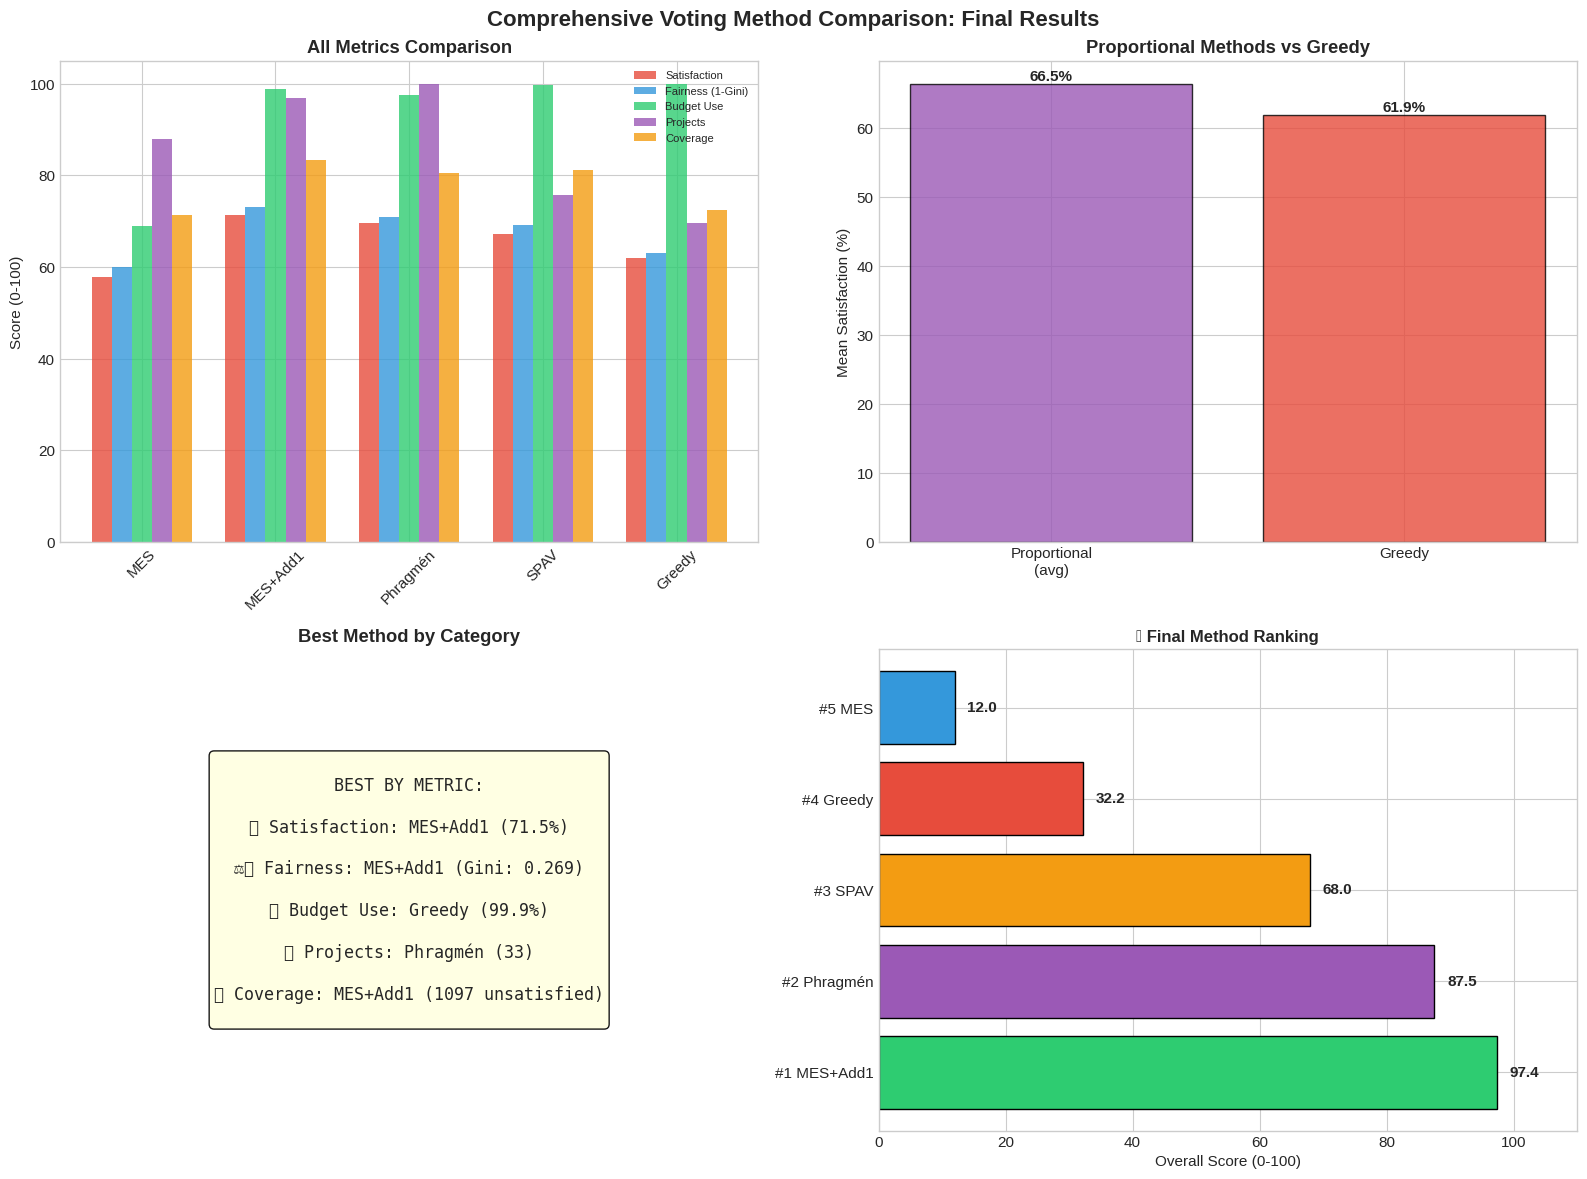


FINAL ANALYSIS SUMMARY
  #1: MES+Add1     - Overall Score: 97.4/100
  #2: Phragmén     - Overall Score: 87.5/100
  #3: SPAV         - Overall Score: 68.0/100
  #4: Greedy       - Overall Score: 32.2/100
  #5: MES          - Overall Score: 12.0/100


In [ ]:
# Final comprehensive dashboard - Method Rankings
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = ['MES', 'MES+Add1', 'Phragmén', 'SPAV', 'Greedy']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

all_sets = [set(mes_selected), mes_add1_combined, set(phragmen_selected), set(spav_selected), set(greedy_selected)]
sat_data = [sat_mes, sat_mes_add1, sat_phragmen, sat_spav, sat_greedy]

# Calculate all metrics
proj_counts = [len(s) for s in all_sets]
mean_sats = [np.mean(s)*100 for s in sat_data]
gini_scores = [gini_coefficient(s) for s in sat_data]
spending = [mes_spent, mes_spent+add1_spent, phragmen_spent, spav_spent, greedy_spent]
util = [s/budget*100 for s in spending]
zero_counts = [sum(1 for s in sat if s == 0) for sat in sat_data]

# 1. Radar-style comparison (grouped bars)
ax1 = axes[0, 0]
x = np.arange(5)
width = 0.15
metrics_data = {
    'Satisfaction': mean_sats,
    'Fairness (1-Gini)': [(1-g)*100 for g in gini_scores],
    'Budget Use': util,
    'Projects': [c/max(proj_counts)*100 for c in proj_counts],
    'Coverage': [(len(sat_data[i])-zero_counts[i])/len(sat_data[i])*100 for i in range(5)]
}
metric_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
for i, (metric, values) in enumerate(metrics_data.items()):
    ax1.bar(x + (i-2)*width, values, width, label=metric, color=metric_colors[i], alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.set_ylabel('Score (0-100)')
ax1.set_title('All Metrics Comparison', fontweight='bold')
ax1.legend(loc='upper right', fontsize=8)
ax1.tick_params(axis='x', rotation=45)

# 2. Proportional methods vs Greedy
ax2 = axes[0, 1]
proportional_avg = np.mean([mean_sats[i] for i in [0, 1, 2, 3]])  # MES, MES+Add1, Phragmen, SPAV
greedy_val = mean_sats[4]
ax2.bar(['Proportional\n(avg)', 'Greedy'], [proportional_avg, greedy_val],
        color=['#9b59b6', '#e74c3c'], edgecolor='black', alpha=0.8)
ax2.set_ylabel('Mean Satisfaction (%)')
ax2.set_title('Proportional Methods vs Greedy', fontweight='bold')
for i, v in enumerate([proportional_avg, greedy_val]):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

# 3. Winner summary
ax3 = axes[1, 0]
# Find best method for each metric
best_satisfaction = methods[np.argmax(mean_sats)]
best_fairness = methods[np.argmin(gini_scores)]
best_budget = methods[np.argmax(util)]
best_projects = methods[np.argmax(proj_counts)]
best_coverage = methods[np.argmin(zero_counts)]

summary_text = f"""
BEST BY METRIC:

📊 Satisfaction: {best_satisfaction} ({max(mean_sats):.1f}%)

⚖️ Fairness: {best_fairness} (Gini: {min(gini_scores):.3f})

💰 Budget Use: {best_budget} ({max(util):.1f}%)

📋 Projects: {best_projects} ({max(proj_counts)})

👥 Coverage: {best_coverage} ({min(zero_counts)} unsatisfied)
"""
ax3.text(0.5, 0.5, summary_text, transform=ax3.transAxes, fontsize=12,
         verticalalignment='center', horizontalalignment='center',
         family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax3.axis('off')
ax3.set_title('Best Method by Category', fontweight='bold')

# 4. Final ranking with scores
ax4 = axes[1, 1]
# Compute overall normalized scores
def normalize(values, higher_better=True):
    min_v, max_v = min(values), max(values)
    if max_v == min_v:
        return [50]*len(values)
    if higher_better:
        return [(v-min_v)/(max_v-min_v)*100 for v in values]
    else:
        return [(max_v-v)/(max_v-min_v)*100 for v in values]

norm_sat = normalize(mean_sats, True)
norm_fair = normalize(gini_scores, False)  # Lower is better
norm_budget = normalize(util, True)
norm_projects = normalize(proj_counts, True)
norm_coverage = normalize(zero_counts, False)  # Lower is better

overall = [(norm_sat[i] + norm_fair[i] + norm_budget[i] + norm_projects[i] + norm_coverage[i])/5
           for i in range(5)]

# Sort by overall score
ranked = sorted(zip(methods, overall, colors), key=lambda x: x[1], reverse=True)

bars = ax4.barh(range(5), [r[1] for r in ranked], color=[r[2] for r in ranked], edgecolor='black')
ax4.set_yticks(range(5))
ax4.set_yticklabels([f'#{i+1} {r[0]}' for i, r in enumerate(ranked)], fontsize=11)
ax4.set_xlabel('Overall Score (0-100)')
ax4.set_title('🏆 Final Method Ranking', fontweight='bold', fontsize=12)
ax4.set_xlim(0, 110)
for i, (method, score, color) in enumerate(ranked):
    ax4.text(score + 2, i, f'{score:.1f}', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Comprehensive Voting Method Comparison: Final Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print final summary
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY")
print("="*60)
for i, (method, score, _) in enumerate(ranked):
    print(f"  #{i+1}: {method:<12} - Overall Score: {score:.1f}/100")
print("="*60)
